# ExoHunter-ML - notebook de experimentos

aqui ta tudo que eu testei, incluindo o que nao deu certo. o entregavel so tem a versao final limpa.

dataset: kepler labelled time series (kaggle)

## 1. ambiente

fixei a seed pra poder comparar as tentativas depois

In [ ]:
!pip -q install numpy pandas scipy scikit-learn matplotlib seaborn tensorflow shap kagglehub

In [ ]:
!pip -q install kagglehub

In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
import kagglehub

# download do dataset
dataset_path = kagglehub.dataset_download(
    "keplersmachines/kepler-labelled-time-series-data"
)

print("Dataset baixado em:")
print(dataset_path)

print("\nArquivos encontrados:")
print(os.listdir(dataset_path))

100%|██████████| 55.9M/55.9M [00:03<00:00, 15.6MB/s]

Extracting files...


Dataset baixado em:
/root/.cache/kagglehub/datasets/keplersmachines/kepler-labelled-time-series-data/versions/3

Arquivos encontrados:
['exoTrain.csv', 'exoTest.csv']


In [ ]:
train_path = os.path.join(dataset_path, "exoTrain.csv")
test_path = os.path.join(dataset_path, "exoTest.csv")

# carregamento
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Treinamento:", train.shape)
print("Teste:", test.shape)

Treinamento: (5087, 3198)
Teste: (570, 3198)


## 2. primeira olhada nos dados

shape, colunas, distribuicao do label - antes de mexer em qualquer coisa

In [ ]:
train.shape

(5087, 3198)

In [ ]:
test.shape

(570, 3198)

In [ ]:
train.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [ ]:
test.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,119.88,100.21,86.46,48.68,46.12,39.39,18.57,6.98,6.63,...,14.52,19.29,14.44,-1.62,13.33,45.50,31.93,35.78,269.43,57.72
1,2,5736.59,5699.98,5717.16,5692.73,5663.83,5631.16,5626.39,5569.47,5550.44,...,-581.91,-984.09,-1230.89,-1600.45,-1824.53,-2061.17,-2265.98,-2366.19,-2294.86,-2034.72
2,2,844.48,817.49,770.07,675.01,605.52,499.45,440.77,362.95,207.27,...,17.82,-51.66,-48.29,-59.99,-82.10,-174.54,-95.23,-162.68,-36.79,30.63
3,2,-826.00,-827.31,-846.12,-836.03,-745.50,-784.69,-791.22,-746.50,-709.53,...,122.34,93.03,93.03,68.81,9.81,20.75,20.25,-120.81,-257.56,-215.41
4,2,-39.57,-15.88,-9.16,-6.37,-16.13,-24.05,-0.90,-45.20,-5.04,...,-37.87,-61.85,-27.15,-21.18,-33.76,-85.34,-81.46,-61.98,-69.34,-17.84


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB


In [ ]:
train["LABEL"].value_counts()

,count
LABEL,
1,5050
2,37


In [ ]:
train["LABEL"].value_counts(normalize=True)

,proportion
LABEL,
1,0.992727
2,0.007273


In [ ]:
test["LABEL"].value_counts()

,count
LABEL,
1,565
2,5


desbalanceado pra caramba: 5050 sem exoplaneta vs 37 com (treino), 565 vs 5 (teste)

accuracy sozinha nao vai servir pra avaliar isso

# 4. Exploratory Data Analysis (EDA)

Nesta etapa é realizada uma análise exploratória dos dados com o objetivo de compreender:

- a distribuição das classes;
- a estrutura das séries temporais;
- a presença de valores ausentes ou inválidos;
- a distribuição dos valores de fluxo;
- diferenças entre as classes;
- características relevantes para as etapas posteriores de modelagem.

In [ ]:
# valores perdidos

print("Valores ausentes no treino:", train.isna().sum().sum())
print("Valores ausentes no teste:", test.isna().sum().sum())

Valores ausentes no treino: 0
Valores ausentes no teste: 0


In [ ]:
# valores infinitos

train_numeric = train.drop(columns=["LABEL"])
test_numeric = test.drop(columns=["LABEL"])

print(
    "Valores infinitos no treino:",
    np.isinf(train_numeric.to_numpy()).sum()
)

print(
    "Valores infinitos no teste:",
    np.isinf(test_numeric.to_numpy()).sum()
)

Valores infinitos no treino: 0
Valores infinitos no teste: 0


In [ ]:
# duplicados

print("Linhas duplicadas no treino:", train.duplicated().sum())
print("Linhas duplicadas no teste:", test.duplicated().sum())

Linhas duplicadas no treino: 0
Linhas duplicadas no teste: 0


In [ ]:
train.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
LABEL,5087.0,1.007273,0.084982,1.00,1.000,1.00,1.000,2.0
FLUX.1,5087.0,144.505445,21506.686590,-227856.26,-42.340,-0.71,48.255,1439240.5
FLUX.2,5087.0,128.577834,21797.167583,-315440.76,-39.520,-0.89,44.285,1453319.0
FLUX.3,5087.0,147.134789,21913.092010,-284001.76,-38.505,-0.74,42.325,1468429.0
FLUX.4,5087.0,156.151203,22233.659938,-234006.87,-35.050,-0.40,39.765,1495750.0
FLUX.5,5087.0,156.147672,23084.480467,-423195.62,-31.955,-0.61,39.750,1510937.0
FLUX.6,5087.0,146.964555,24105.667275,-597552.12,-33.380,-1.03,35.140,1508152.5
FLUX.7,5087.0,116.838017,24141.087257,-672404.56,-28.130,-0.87,34.060,1465743.0
FLUX.8,5087.0,114.498305,22906.907754,-579013.56,-27.840,-0.66,31.700,1416827.0
FLUX.9,5087.0,122.863880,21026.809919,-397388.24,-26.835,-0.56,30.455,1342888.5


testei umas stats simples (media, desvio, min, max, amplitude) antes de fazer a extracao de features de verdade, so pra ver se ja separa as classes

In [ ]:
# estatísticas das curvas de luz

flux_columns = [col for col in train.columns if col.startswith("FLUX.")]

train["flux_mean"] = train[flux_columns].mean(axis=1)
train["flux_std"] = train[flux_columns].std(axis=1)
train["flux_min"] = train[flux_columns].min(axis=1)
train["flux_max"] = train[flux_columns].max(axis=1)
train["flux_range"] = train["flux_max"] - train["flux_min"]

train[
    ["LABEL", "flux_mean", "flux_std", "flux_min",
     "flux_max", "flux_range"]
].describe()

,LABEL,flux_mean,flux_std,flux_min,flux_max,flux_range
count,5087.000000,5087.000000,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03
mean,1.007273,130.416740,1.266201e+03,-3.400774e+03,5.290579e+03,8.691353e+03
std,0.084982,6274.662626,2.112921e+04,4.741708e+04,8.630058e+04,1.249824e+05
min,1.000000,-72469.378492,1.704936e+00,-2.385019e+06,1.155000e+01,1.857000e+01
25%,1.000000,-0.889609,1.638256e+01,-6.300700e+02,2.361550e+02,3.515350e+02
50%,1.000000,0.425393,4.015456e+01,-1.988500e+02,5.181400e+02,8.138200e+02
75%,1.000000,1.912918,1.119359e+02,-5.348000e+01,1.114015e+03,1.837440e+03
max,2.000000,384038.517047,1.053407e+06,-5.540000e+00,4.299288e+06,5.026644e+06


desvio padrao da flux_mean ta gigante comparado com a media - outlier puxando forte. vejo isso melhor na secao 4

### distribuicao das classes

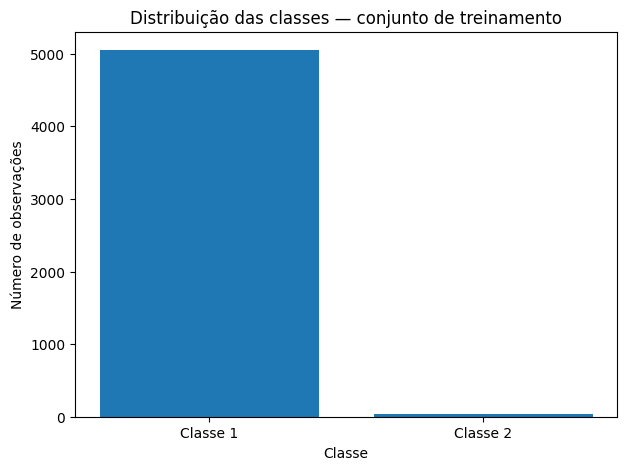

In [ ]:
# class distribution

class_counts = train["LABEL"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Classe 1", "Classe 2"],
    class_counts.values
)

plt.title("Distribuição das classes — conjunto de treinamento")
plt.xlabel("Classe")
plt.ylabel("Número de observações")

plt.show()

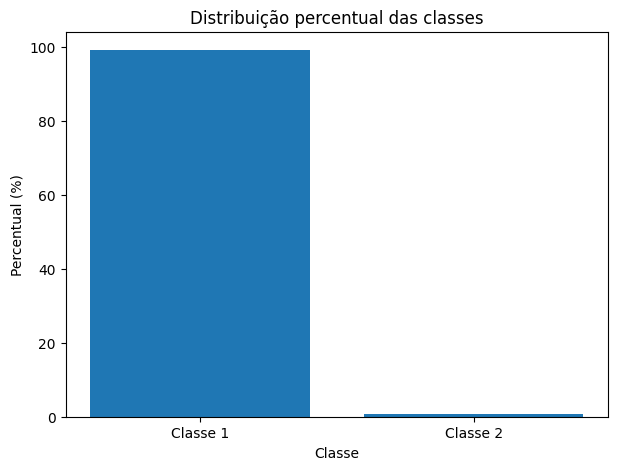

In [ ]:
class_percentages = train["LABEL"].value_counts(
    normalize=True
).sort_index() * 100

plt.figure(figsize=(7, 5))

plt.bar(
    ["Classe 1", "Classe 2"],
    class_percentages.values
)

plt.title("Distribuição percentual das classes")
plt.xlabel("Classe")
plt.ylabel("Percentual (%)")

plt.show()

In [ ]:
# exemplos

positive_sample = train[train["LABEL"] == 2].iloc[0]
negative_sample = train[train["LABEL"] == 1].iloc[0]

positive_flux = positive_sample[flux_columns].values.astype(float)
negative_flux = negative_sample[flux_columns].values.astype(float)

time = np.arange(len(flux_columns))

### curvas de luz cruas

queria ver como as curvas sao de verdade antes de processar nada

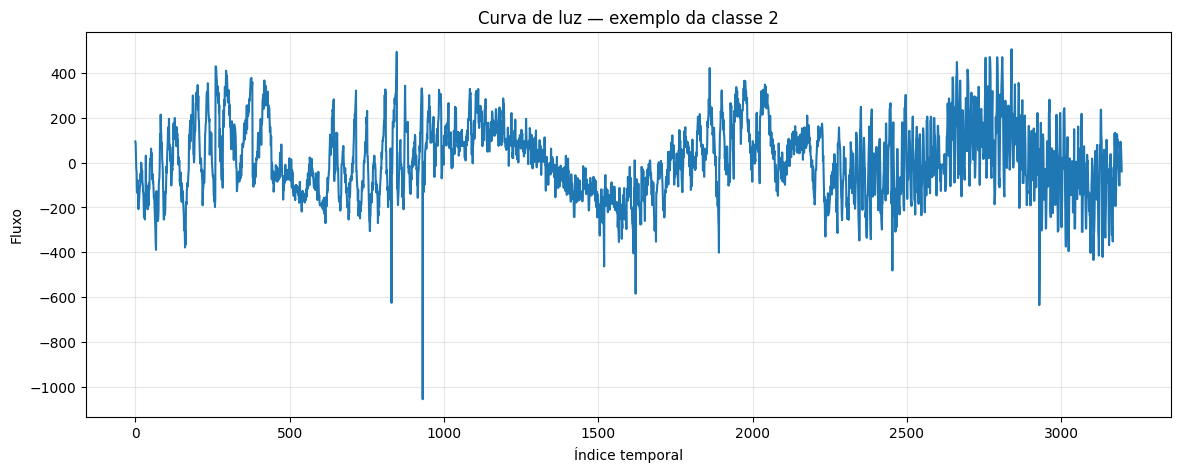

In [ ]:
# curva de luz — exemplo positivo

plt.figure(figsize=(14, 5))

plt.plot(time, positive_flux)

plt.title("Curva de luz — exemplo da classe 2")
plt.xlabel("Índice temporal")
plt.ylabel("Fluxo")

plt.grid(alpha=0.3)
plt.show()

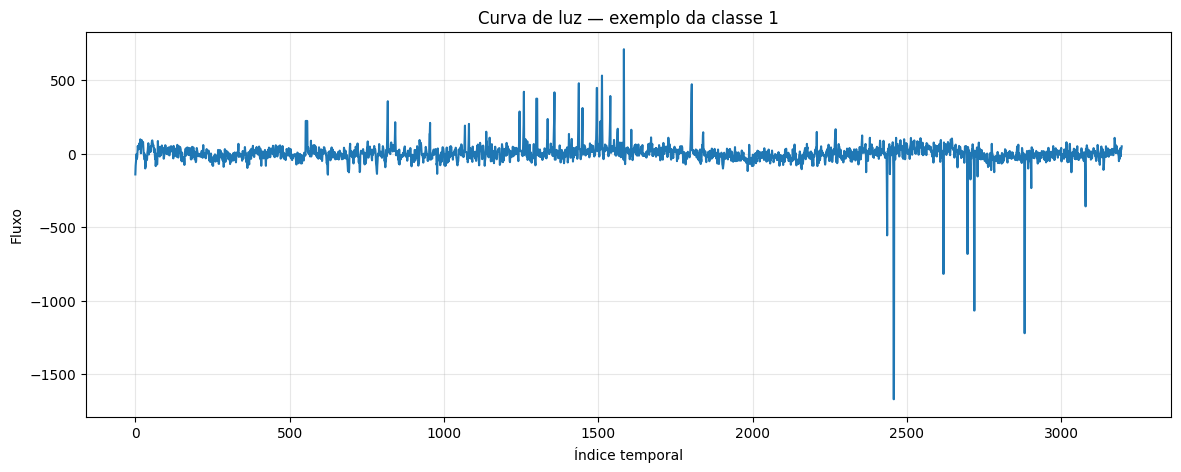

In [ ]:
# negativo

plt.figure(figsize=(14, 5))

plt.plot(time, negative_flux)

plt.title("Curva de luz — exemplo da classe 1")
plt.xlabel("Índice temporal")
plt.ylabel("Fluxo")

plt.grid(alpha=0.3)
plt.show()

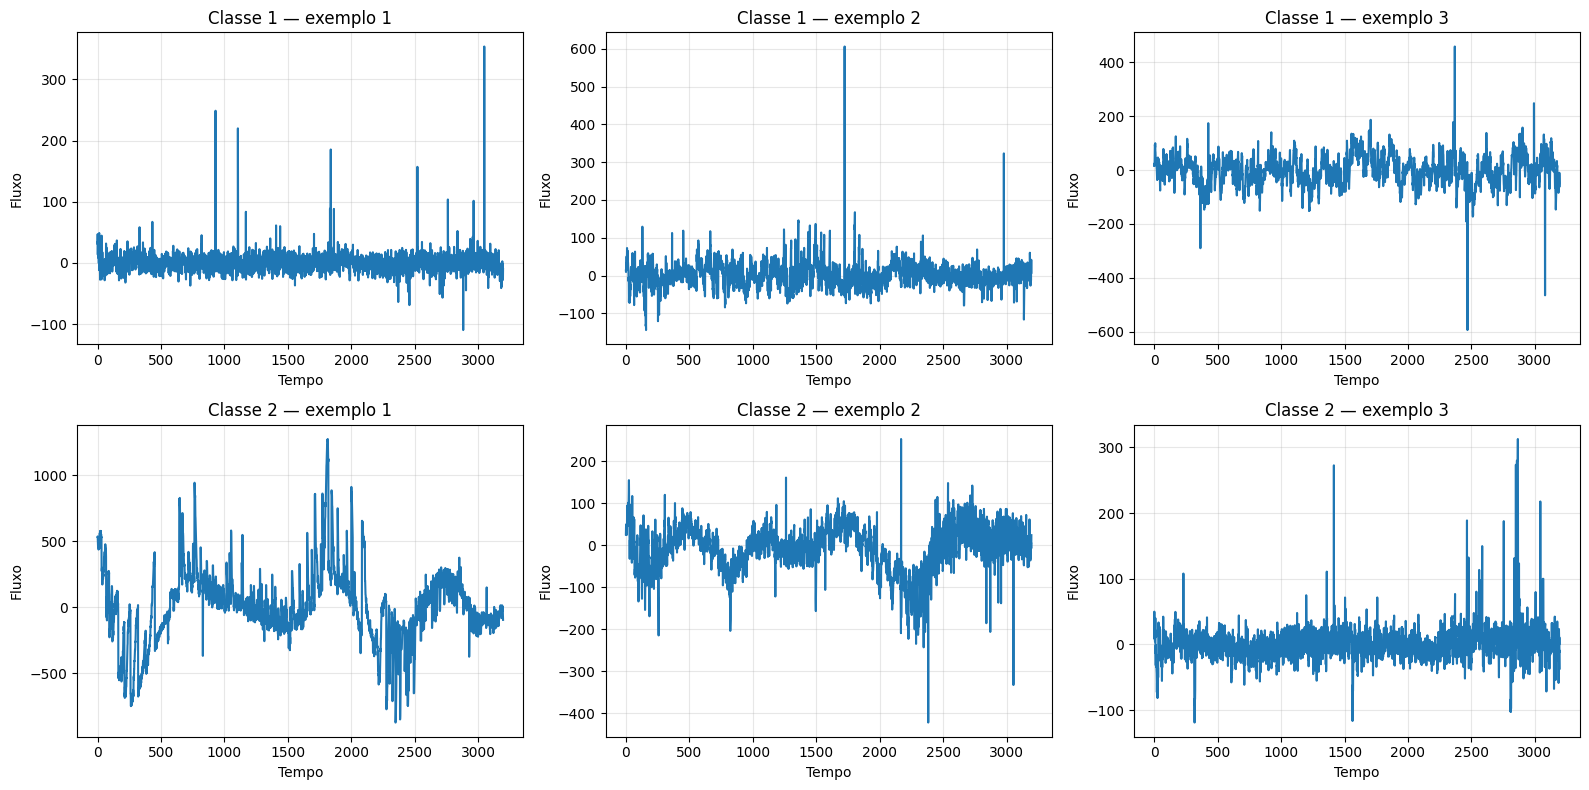

In [ ]:
# multiple light curves

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, label, title in zip(
    axes.flatten(),
    [1, 1, 1, 2, 2, 2],
    [
        "Classe 1 — exemplo 1",
        "Classe 1 — exemplo 2",
        "Classe 1 — exemplo 3",
        "Classe 2 — exemplo 1",
        "Classe 2 — exemplo 2",
        "Classe 2 — exemplo 3",
    ]
):

    sample = train[train["LABEL"] == label].iloc[
        np.random.randint(
            len(train[train["LABEL"] == label])
        )
    ]

    flux = sample[flux_columns].values.astype(float)

    ax.plot(time, flux)
    ax.set_title(title)
    ax.set_xlabel("Tempo")
    ax.set_ylabel("Fluxo")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

refiz as checagens de qualidade aqui de novo, meio redundante mas foi assim que rodei

In [ ]:
print("Valores ausentes no treino:", train.isna().sum().sum())
print("Valores ausentes no teste:", test.isna().sum().sum())

Valores ausentes no treino: 0
Valores ausentes no teste: 0


In [ ]:
print(
    "Valores infinitos no treino:",
    np.isinf(train.drop(columns=["LABEL"]).to_numpy()).sum()
)

print(
    "Valores infinitos no teste:",
    np.isinf(test.drop(columns=["LABEL"]).to_numpy()).sum()
)

Valores infinitos no treino: 0
Valores infinitos no teste: 0


In [ ]:
print("Linhas duplicadas no treino:", train.duplicated().sum())
print("Linhas duplicadas no teste:", test.duplicated().sum())

Linhas duplicadas no treino: 0
Linhas duplicadas no teste: 0


# 5. Análise da escala e distribuição dos sinais

As curvas de luz apresentam amplitudes distintas entre as observações.
Nesta etapa, será investigada a distribuição das amplitudes e a necessidade
de normalização individual das séries antes da modelagem.

stats globais (media das medias, desvio dos desvios, min/max) so pra ter nocao de ordem de grandeza

In [ ]:
# distribuição das estatísticas das curvas

flux_columns = [col for col in train.columns if col.startswith("FLUX.")]

curve_mean = train[flux_columns].mean(axis=1)
curve_std = train[flux_columns].std(axis=1)
curve_min = train[flux_columns].min(axis=1)
curve_max = train[flux_columns].max(axis=1)

print("Média das médias:", curve_mean.mean())
print("Desvio das médias:", curve_mean.std())

print("\nMédia dos desvios padrão:", curve_std.mean())
print("Desvio dos desvios padrão:", curve_std.std())

print("\nMenor valor observado:", curve_min.min())
print("Maior valor observado:", curve_max.max())

Média das médias: 130.41674038757083
Desvio das médias: 6274.66262563499

Média dos desvios padrão: 1266.2005313519119
Desvio dos desvios padrão: 21129.21036915421

Menor valor observado: -2385019.12
Maior valor observado: 4299288.0


In [ ]:
# estatísticas por classe

eda = pd.DataFrame({
    "LABEL": train["LABEL"],
    "mean": curve_mean,
    "std": curve_std,
    "min": curve_min,
    "max": curve_max
})

eda.groupby("LABEL").agg(
    ["mean", "median", "std", "min", "max"]
)

mean                                                      \
             mean    median          std           min            max   
LABEL                                                                   
1      131.717442  0.427585  6297.569001 -72469.378492  384038.517047   
2      -47.111464 -3.969603   206.443572  -1206.410288     209.115934   

               std                                                     \
              mean      median           std        min           max   
LABEL                                                                   
1      1267.318598   39.799796  21202.434703   1.704936  1.053407e+06   
2      1113.599545  155.684307   4907.829991  18.700218  2.999875e+04   

              min                                                    max  \
             mean   median           std         min    max         mean   
LABEL                                                                      
1     -3393.83822 -196.945  47562.479754 -2385019.12  -5.54  5291.525873   
2     -4347.37027 -613.060  19314.150039  -118381.30 -93.91  5161.361622   

                                                
       median           std     min        max  
LABEL                                           
1      517.46  86591.259404   11.55  4299288.0  
2      783.26  24621.976729  171.28   150725.8

### classe 1 distorcida por outlier

desvio e range da classe 1 tao bem maiores que a classe 2, o que nao faz sentido (classe 1 e a majoritaria/normal). deve ter uns exemplos puxando pra cima. bora ver os percentis

In [ ]:
# análise de valores extremos (foi observado que a classe 1 está sendo fortemente distorcida por valore extremos)

flux_values = train[flux_columns].to_numpy()

print("Percentis globais dos valores de fluxo:")

percentiles = np.percentile(
    flux_values,
    [0, 0.01, 0.1, 1, 5, 25, 50, 75, 95, 99, 99.9, 99.99, 100]
)

for p, value in zip(
    [0, 0.01, 0.1, 1, 5, 25, 50, 75, 95, 99, 99.9, 99.99, 100],
    percentiles
):
    print(f"{p:6.2f}% → {value:,.4f}")

Percentis globais dos valores de fluxo:
  0.00% → -2,385,019.1200
  0.01% → -470,202.4631
  0.10% → -67,020.1876
  1.00% → -2,791.0000
  5.00% → -232.6900
 25.00% → -16.0100
 50.00% → 0.0000
 75.00% → 17.0500
 95.00% → 244.1300
 99.00% → 2,738.3162
 99.90% → 66,734.0000
 99.99% → 818,607.3232
100.00% → 4,299,288.0000


99% do fluxo ta entre -2791 e 2738, mas o max absoluto passa de 4 milhoes. cauda bem fina e bem longe do resto. vamo achar essas curvas

In [ ]:
# curvas com maiores valores absolutos

curve_abs_max = train[flux_columns].abs().max(axis=1)

extreme_indices = curve_abs_max.nlargest(10).index

extreme_info = pd.DataFrame({
    "LABEL": train.loc[extreme_indices, "LABEL"],
    "max_abs_flux": curve_abs_max.loc[extreme_indices]
}).sort_values(
    "max_abs_flux",
    ascending=False
)

extreme_info

,LABEL,max_abs_flux
778,1,4299288.00
954,1,2641624.75
497,1,1612730.00
3340,1,1510937.00
4493,1,1419728.00
4202,1,1242173.00
4186,1,1212507.00
1951,1,1089714.00
2739,1,1054388.00
1814,1,743790.50


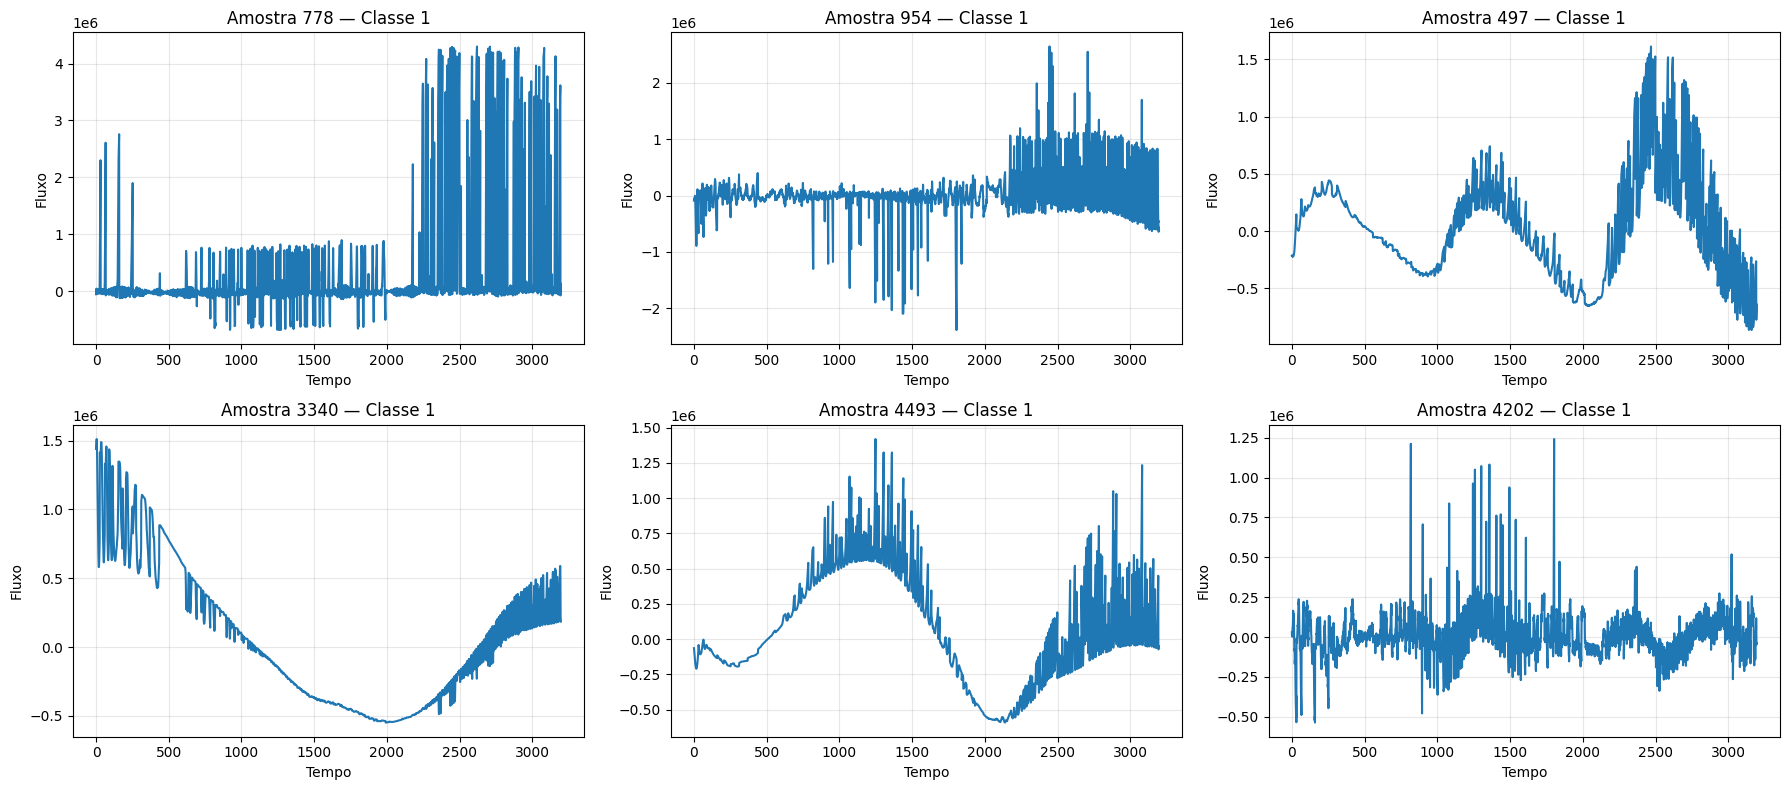

In [ ]:
# visualização das curvas mais extremas

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 8)
)

for ax, idx in zip(
    axes.flatten(),
    extreme_indices[:6]
):

    label = train.loc[idx, "LABEL"]
    flux = train.loc[idx, flux_columns].values.astype(float)

    ax.plot(time, flux)

    ax.set_title(
        f"Amostra {idx} — Classe {label}"
    )

    ax.set_xlabel("Tempo")
    ax.set_ylabel("Fluxo")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

as 10 curvas com maior valor absoluto sao todas classe 1 - deve ser artefato de sensor, nao transito de verdade

### stats robustas (mediana/mad)

media e desvio sao sensiveis a outlier, entao testei mediana e mad no lugar

In [ ]:
# estatísticas

curve_median = train[flux_columns].median(axis=1)

curve_mad = train[flux_columns].apply(
    lambda row: np.median(
        np.abs(row - np.median(row))
    ),
    axis=1
)

robust_stats = pd.DataFrame({
    "LABEL": train["LABEL"],
    "median": curve_median,
    "MAD": curve_mad
})

robust_stats.groupby("LABEL").agg(
    ["mean", "median", "std", "min", "max"]
)

median                                      MAD                      \
           mean median      std    min   max        mean median          std   
LABEL                                                                          
1      0.000000   0.00  0.00000   0.00  0.00  619.387943  17.99  9227.803792   
2     -0.385405  -0.01  2.20986 -13.02  1.09  772.132162  61.11  3489.793178   

                        
        min        max  
LABEL                   
1      1.02  388686.00  
2      7.48   21260.93

mediana da classe 1 = 0 (faz sentido), mad bem menor que o desvio - mais estavel

### quantificando os outliers

quantos pontos/curvas passam de diferentes limiares de valor absoluto

In [ ]:
# quantificação de valores extremos

thresholds = [1_000, 5_000, 10_000, 100_000]

print("PERCENTUAL DE PONTOS EXTREMOS POR CLASSE\n")

for threshold in thresholds:

    print(f"|x| > {threshold:,}")

    mask = train[flux_columns].abs() > threshold

    for label in [1, 2]:

        class_mask = train["LABEL"] == label

        total_points = mask.loc[class_mask].to_numpy().sum()
        total_possible = class_mask.sum() * len(flux_columns)

        percentage = (
            100 * total_points / total_possible
        )

        curves_affected = (
            mask.loc[class_mask]
            .any(axis=1)
            .sum()
        )

        total_curves = class_mask.sum()

        print(
            f"  Classe {label}: "
            f"{total_points:,} pontos "
            f"({percentage:.6f}%) | "
            f"{curves_affected}/{total_curves} curvas"
        )

    print()

PERCENTUAL DE PONTOS EXTREMOS POR CLASSE

|x| > 1,000
  Classe 1: 642,070 pontos (3.976934%) | 1640/5050 curvas
  Classe 2: 9,707 pontos (8.206173%) | 20/37 curvas

|x| > 5,000
  Classe 1: 204,963 pontos (1.269526%) | 360/5050 curvas
  Classe 2: 2,799 pontos (2.366239%) | 2/37 curvas

|x| > 10,000
  Classe 1: 128,908 pontos (0.798447%) | 170/5050 curvas
  Classe 2: 2,425 pontos (2.050064%) | 1/37 curvas

|x| > 100,000
  Classe 1: 23,575 pontos (0.146022%) | 31/5050 curvas
  Classe 2: 10 pontos (0.008454%) | 1/37 curvas



32,6% das curvas tem ponto acima de 1000 em modulo, cai pra 0,6% acima de 100000. outlier moderado e comum, extremo e raro

In [ ]:
# concentração dos valores extremos

curve_max_abs = train[flux_columns].abs().max(axis=1)

for threshold in [1_000, 5_000, 10_000, 100_000]:

    affected = curve_max_abs > threshold

    print(
        f"|max(flux)| > {threshold:,}: "
        f"{affected.sum()} curvas "
        f"({100 * affected.mean():.3f}%)"
    )

|max(flux)| > 1,000: 1660 curvas (32.632%)
|max(flux)| > 5,000: 362 curvas (7.116%)
|max(flux)| > 10,000: 171 curvas (3.362%)
|max(flux)| > 100,000: 32 curvas (0.629%)


### normalizacao robusta (mediana/mad) so pra visualizar

criei essa normalizacao pra poder comparar curvas de classes diferentes na mesma escala

In [ ]:
# normalização robusta para visualização

def robust_normalize_curve(x):
    median = np.median(x)
    mad = np.median(np.abs(x - median))

    if mad < 1e-8:
        scale = np.std(x)

        if scale < 1e-8:
            scale = 1.0
    else:
        scale = mad

    return (x - median) / scale

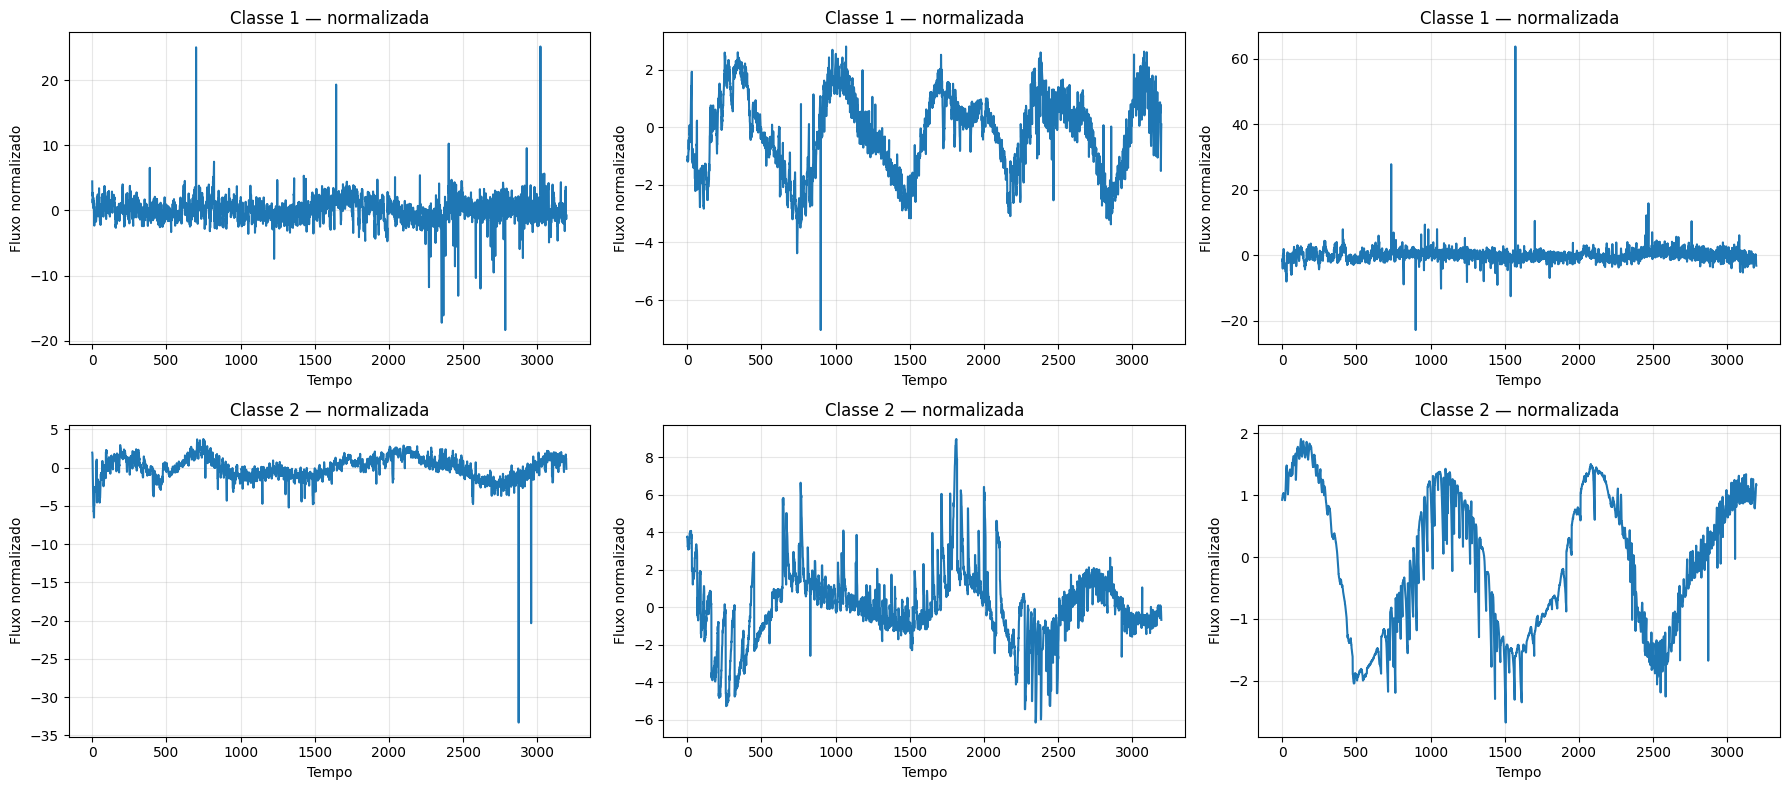

In [ ]:
# comparação visual pós normalização

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 8)
)

for ax, label, title in zip(
    axes.flatten(),
    [1, 1, 1, 2, 2, 2],
    [
        "Classe 1 — normalizada",
        "Classe 1 — normalizada",
        "Classe 1 — normalizada",
        "Classe 2 — normalizada",
        "Classe 2 — normalizada",
        "Classe 2 — normalizada",
    ]
):

    candidates = train[train["LABEL"] == label]

    sample = candidates.iloc[
        np.random.randint(len(candidates))
    ]

    flux = sample[flux_columns].values.astype(float)

    normalized_flux = robust_normalize_curve(flux)

    ax.plot(time, normalized_flux)

    ax.set_title(title)
    ax.set_xlabel("Tempo")
    ax.set_ylabel("Fluxo normalizado")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

da pra comparar a forma das curvas sem a escala atrapalhar

## 5. engenharia de atributos

3197 pontos de fluxo direto e dimensao demais pra so 37 positivos. decidi resumir cada curva em 15 estatisticas: media, mediana, std, mad, min, max, range, quantis (q01-q99), skewness, kurtosis. essa primeira versao usa apply linha a linha

In [ ]:

# Engenharia de atributos estatísticos!

from scipy.stats import skew, kurtosis

def extract_features(row):
    x = row[flux_columns].values.astype(float)

    median = np.median(x)
    mad = np.median(np.abs(x - median))

    return pd.Series({
        "median": median,
        "mad": mad,
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "max": np.max(x),
        "range": np.max(x) - np.min(x),

        "q01": np.percentile(x, 1),
        "q05": np.percentile(x, 5),
        "q25": np.percentile(x, 25),
        "q75": np.percentile(x, 75),
        "q95": np.percentile(x, 95),
        "q99": np.percentile(x, 99),

        "skewness": skew(x),
        "kurtosis": kurtosis(x)
    })


stat_features = train.apply(extract_features, axis=1)

stat_features["LABEL"] = train["LABEL"].values

stat_features.head()

,median,mad,mean,std,min,max,range,q01,q05,q25,q75,q95,q99,skewness,kurtosis,LABEL
0,-0.01,110.89,9.953857,160.703348,-1053.97,504.46,1558.43,-334.4648,-236.350,-103.40,118.68,285.098,376.6556,0.004392,0.408338,2
1,0.01,23.41,-7.427932,60.001638,-371.27,252.64,623.91,-292.7304,-84.068,-25.18,21.43,54.402,118.6992,-2.273858,10.046725,2
2,-0.08,142.13,8.189087,281.832397,-874.95,1274.59,2149.54,-708.2948,-503.860,-129.67,158.31,477.300,858.8148,0.358542,2.200535,2
3,-0.01,72.91,-4.646587,103.222575,-268.41,370.29,638.70,-227.8400,-177.054,-78.19,69.52,143.984,275.9224,-0.004433,-0.029248,2
4,0.02,296.36,-14.240660,407.057614,-1808.76,924.32,2733.08,-1016.6600,-764.244,-268.09,315.40,547.698,765.3300,-0.527380,0.144301,2


In [ ]:
# estatísticas agrupadas por classe

stats_by_class = stat_features.groupby("LABEL").agg(
    ["mean", "median", "std"]
)

stats_by_class

median                         mad                            mean  \
           mean median      std        mean median          std        mean   
LABEL                                                                         
1      0.000000   0.00  0.00000  619.387943  17.99  9227.803792  131.717442   
2     -0.385405  -0.01  2.20986  772.132162  61.11  3489.793178  -47.111464   

                                      std  ...           q95          q99  \
         median          std         mean  ...           std         mean   
LABEL                                      ...                              
1      0.427585  6297.569001  1267.120378  ...  56761.334579  3340.683520   
2     -3.969603   206.443572  1113.425369  ...   7120.068232  2506.365265   

                               skewness                         kurtosis  \
         median           std      mean    median        std        mean   
LABEL                                                                      
1       88.8652  72181.072559  4.692929  1.196722  10.416770  199.189562   
2      275.9224  11771.628697 -0.011499  0.000591   4.322753   38.441678   

                              
          median         std  
LABEL                         
1      21.521243  454.675484  
2       5.361787  137.133170  

[2 rows x 45 columns]

### e as mesmas features nas curvas normalizadas?

ja tinha a normalizacao pronta, entao testei extrair as features dela tambem

In [ ]:
# extração de atributos pós normalização

normalized_features = []

for _, row in train.iterrows():

    x = row[flux_columns].values.astype(float)

    x_norm = robust_normalize_curve(x)

    normalized_features.append({
        "median": np.median(x_norm),
        "mad": np.median(np.abs(x_norm - np.median(x_norm))),
        "mean": np.mean(x_norm),
        "std": np.std(x_norm),
        "min": np.min(x_norm),
        "max": np.max(x_norm),
        "range": np.max(x_norm) - np.min(x_norm),

        "q01": np.percentile(x_norm, 1),
        "q05": np.percentile(x_norm, 5),
        "q25": np.percentile(x_norm, 25),
        "q75": np.percentile(x_norm, 75),
        "q95": np.percentile(x_norm, 95),
        "q99": np.percentile(x_norm, 99),

        "skewness": skew(x_norm),
        "kurtosis": kurtosis(x_norm),

        "LABEL": row["LABEL"]
    })


normalized_features = pd.DataFrame(normalized_features)

normalized_features.head()

,median,mad,mean,std,min,max,range,q01,q05,q25,q75,q95,q99,skewness,kurtosis,LABEL
0,0.0,1.0,0.089854,1.449214,-9.504554,4.549283,14.053837,-3.016095,-2.131301,-0.932365,1.070340,2.571088,3.396750,0.004392,0.408338,2.0
1,0.0,1.0,-0.317725,2.563077,-15.859889,10.791542,26.651431,-12.504930,-3.591542,-1.076036,0.914994,2.323452,5.070021,-2.273858,10.046725,2.0
2,0.0,1.0,0.058180,1.982920,-6.155421,8.968339,15.123760,-4.982866,-3.544502,-0.911771,1.114402,3.358756,6.043023,0.358542,2.200535,2.0
3,0.0,1.0,-0.063593,1.415753,-3.681251,5.078864,8.760115,-3.124811,-2.428254,-1.072281,0.953641,1.974955,3.784562,-0.004433,-0.029248,2.0
4,0.0,1.0,-0.048119,1.373524,-6.103320,3.118842,9.222162,-3.430557,-2.578837,-0.904677,1.064179,1.848016,2.582366,-0.527380,0.144301,2.0


In [ ]:
normalized_features.groupby("LABEL").agg(
    ["mean", "median", "std"]
)

median              mad                  mean                      \
        mean median  std mean median  std      mean    median       std   
LABEL                                                                     
1.0      0.0    0.0  0.0  1.0    1.0  0.0  0.063785  0.049631  0.345231   
2.0      0.0    0.0  0.0  1.0    1.0  0.0 -0.120523 -0.063593  0.399319   

            std  ...       q95       q99                      skewness  \
           mean  ...       std      mean    median       std      mean   
LABEL            ...                                                     
1.0    2.616431  ...  1.333546  5.311047  4.474828  3.361552  4.692929   
2.0    2.448403  ...  0.901624  4.721611  3.747324  3.144139 -0.011499   

                              kurtosis                         
         median        std        mean     median         std  
LABEL                                                          
1.0    1.196722  10.416770  199.189562  21.521243  454.675484  
2.0    0.000591   4.322753   38.441678   5.361787  137.133170  

[2 rows x 45 columns]

### decidi nao usar as normalizadas

nao separou melhor e perde a escala fisica (range deixa de fazer sentido em unidade real). fico com as features cruas

nota: aqui redefini X como as 3197 colunas de fluxo bruto, isso acaba nao sendo usado direto - o pipeline final usa X_train_features etc

In [ ]:
# separação de atributos e variável-alvo

# dados de treinamento
X = train[flux_columns].copy()
y = train["LABEL"].copy()

# dados de teste
X_test = test[flux_columns].copy()
y_test = test["LABEL"].copy()

print("Treinamento:")
print("X:", X.shape)
print("y:", y.shape)

print("\nTeste:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Treinamento:
X: (5087, 3197)
y: (5087,)

Teste:
X_test: (570, 3197)
y_test: (570,)


In [ ]:
# distribuição das classes

print("Distribuição no treinamento:")
print(y.value_counts().sort_index())

print("\nProporção no treinamento:")
print(y.value_counts(normalize=True).sort_index())

print("\nDistribuição no teste:")
print(y_test.value_counts().sort_index())

print("\nProporção no teste:")
print(y_test.value_counts(normalize=True).sort_index())

Distribuição no treinamento:
LABEL
1    5050
2      37
Name: count, dtype: int64

Proporção no treinamento:
LABEL
1    0.992727
2    0.007273
Name: proportion, dtype: float64

Distribuição no teste:
LABEL
1    565
2      5
Name: count, dtype: int64

Proporção no teste:
LABEL
1    0.991228
2    0.008772
Name: proportion, dtype: float64


In [ ]:
# codificação da variável-alvo

y = (y == 2).astype(int)
y_test = (y_test == 2).astype(int)

print("Treinamento:")
print(y.value_counts().sort_index())

print("\nTeste:")
print(y_test.value_counts().sort_index())

Treinamento:
LABEL
0    5050
1      37
Name: count, dtype: int64

Teste:
LABEL
0    565
1      5
Name: count, dtype: int64


### split treino/val/teste

80/20 estratificado, exoTest.csv fica isolado. validacao fica com so 7 positivos - qualquer erro muda o recall bastante

In [ ]:
# separação treino / validação

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Treino:")
print(X_train.shape, y_train.shape)

print("\nValidação:")
print(X_val.shape, y_val.shape)

print("\nDistribuição das classes:")

print("\nTreino:")
print(y_train.value_counts())

print("\nValidação:")
print(y_val.value_counts())

print("\nTeste:")
print(y_test.value_counts())

Treino:
(4069, 3197) (4069,)

Validação:
(1018, 3197) (1018,)

Distribuição das classes:

Treino:
LABEL
0    4039
1      30
Name: count, dtype: int64

Validação:
LABEL
0    1011
1       7
Name: count, dtype: int64

Teste:
LABEL
0    565
1      5
Name: count, dtype: int64


reescrevi a extracao de features aqui dentro do fluxo treino/val/teste, mesma logica so que organizada

In [ ]:
# engenharia de atributos

from scipy.stats import skew, kurtosis

def extract_statistical_features(df, flux_columns):

    features = []

    for _, row in df.iterrows():

        x = row[flux_columns].values.astype(float)

        median = np.median(x)
        mad = np.median(np.abs(x - median))

        features.append({

            "median": median,
            "mad": mad,

            "mean": np.mean(x),
            "std": np.std(x),

            "min": np.min(x),
            "max": np.max(x),
            "range": np.max(x) - np.min(x),

            "q01": np.percentile(x, 1),
            "q05": np.percentile(x, 5),
            "q25": np.percentile(x, 25),

            "q75": np.percentile(x, 75),
            "q95": np.percentile(x, 95),
            "q99": np.percentile(x, 99),

            "skewness": skew(x),
            "kurtosis": kurtosis(x)
        })

    return pd.DataFrame(features)

In [ ]:
# geração dos atributos

X_train_features = extract_statistical_features(
    X_train,
    flux_columns
)

X_val_features = extract_statistical_features(
    X_val,
    flux_columns
)

X_test_features = extract_statistical_features(
    X_test,
    flux_columns
)

print("Treino:", X_train_features.shape)
print("Validação:", X_val_features.shape)
print("Teste:", X_test_features.shape)

Treino: (4069, 15)
Validação: (1018, 15)
Teste: (570, 15)


### baseline burro primeiro

testei um classificador que nunca preve exoplaneta. com esse desbalanceamento a accuracy fica em ~99% sem aprender nada - serve de piso

In [ ]:
# teste baseline

import numpy as np

y_pred_dummy = np.zeros(len(y_val), dtype=int)

print("Número de previsões positivas:")
print(y_pred_dummy.sum())

print("Total de exemplos:")
print(len(y_pred_dummy))

Número de previsões positivas:
0
Total de exemplos:
1018


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_val, y_pred_dummy))

print("Precision:",
      precision_score(y_val, y_pred_dummy, zero_division=0))

print("Recall:",
      recall_score(y_val, y_pred_dummy, zero_division=0))

print("F1:",
      f1_score(y_val, y_pred_dummy, zero_division=0))

print("\nMatriz de confusão:")
print(confusion_matrix(y_val, y_pred_dummy))

Accuracy: 0.9931237721021611
Precision: 0.0
Recall: 0.0
F1: 0.0

Matriz de confusão:
[[1011    0]
 [   7    0]]


accuracy 99,3% mas precision e recall zerados, como esperado

## 6. primeiro random forest

treinei com class_weight balanced, hiperparametro ainda sem ajuste, so pra comparar com o baseline

In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_features,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
# Previsões

y_pred_rf = rf.predict(X_val_features)

y_prob_rf = rf.predict_proba(X_val_features)[:, 1]

In [ ]:
# avaliação do Random Forest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_val, y_pred_rf))

print("Precision:",
      precision_score(y_val, y_pred_rf, zero_division=0))

print("Recall:",
      recall_score(y_val, y_pred_rf, zero_division=0))

print("F1:",
      f1_score(y_val, y_pred_rf, zero_division=0))

print("ROC-AUC:",
      roc_auc_score(y_val, y_prob_rf))

print("PR-AUC:",
      average_precision_score(y_val, y_prob_rf))

print("\nMatriz de confusão:")
print(confusion_matrix(y_val, y_pred_rf))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_pred_rf,
        target_names=[
            "Sem exoplaneta",
            "Com exoplaneta"
        ],
        zero_division=0
    )
)

Accuracy: 0.9941060903732809
Precision: 1.0
Recall: 0.14285714285714285
F1: 0.25
ROC-AUC: 1.0
PR-AUC: 0.9999999999999998

Matriz de confusão:
[[1011    0]
 [   6    1]]

Classification Report:
                precision    recall  f1-score   support

Sem exoplaneta       0.99      1.00      1.00      1011
Com exoplaneta       1.00      0.14      0.25         7

      accuracy                           0.99      1018
     macro avg       1.00      0.57      0.62      1018
  weighted avg       0.99      0.99      0.99      1018



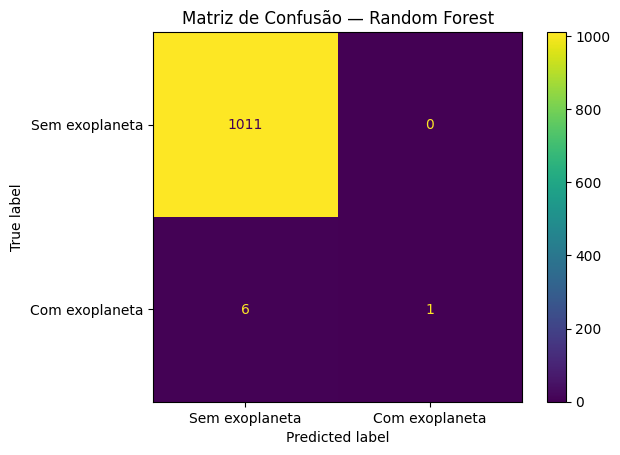

In [ ]:
# Matriz de confusão — Random Forest

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_rf,
    display_labels=[
        "Sem exoplaneta",
        "Com exoplaneta"
    ],
    values_format="d"
)

plt.title("Matriz de Confusão — Random Forest")
plt.show()

### roc-auc perfeito mas recall baixo no threshold padrao

com threshold 0,5: precision 1.0, recall 0,14 (so 1 de 7). mas roc-auc = 1.0

isso quer dizer que o modelo separa bem em ranking, mas as probabilidades ficam baixas demais pro threshold padrao (poucos exemplos positivos no treino). mexo no threshold na secao 8

In [ ]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train_features.columns
).sort_values(ascending=False)

print(feature_importance)

median      0.199538
skewness    0.096316
q01         0.087420
kurtosis    0.070593
min         0.066090
std         0.065711
q99         0.062495
range       0.051615
q75         0.047222
mean        0.046936
q05         0.046454
q95         0.045946
max         0.039795
mad         0.037775
q25         0.036094
dtype: float64


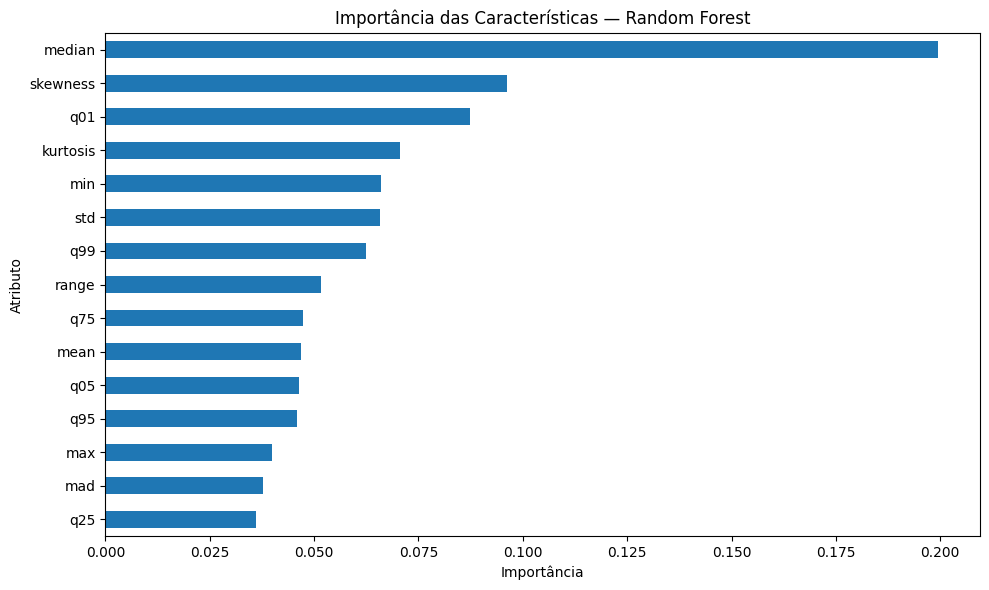

In [ ]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importância")
plt.ylabel("Atributo")
plt.title("Importância das Características — Random Forest")
plt.tight_layout()
plt.show()

## 7. debug: troquei X_val por X_val_features

tentei rodar predict_proba com X_val (fluxo cru) em vez de X_val_features (as 15 stats) e deu erro de mismatch de coluna. fiquei conferindo feature_names_in_ ate achar o erro

In [ ]:
print("Features usadas pelo Random Forest:")
print(rf.feature_names_in_)
print("\nQuantidade:", len(rf.feature_names_in_))

Features usadas pelo Random Forest:
['median' 'mad' 'mean' 'std' 'min' 'max' 'range' 'q01' 'q05' 'q25' 'q75'
 'q95' 'q99' 'skewness' 'kurtosis']

Quantidade: 15


In [ ]:
print("X_train:")
print(X_train.shape)
print(X_train.columns.tolist()[:10])

print("\nX_val:")
print(X_val.shape)
print(X_val.columns.tolist()[:10])

print("\nX_test:")
print(X_test.shape)
print(X_test.columns.tolist()[:10])

X_train:
(4069, 3197)
['FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4', 'FLUX.5', 'FLUX.6', 'FLUX.7', 'FLUX.8', 'FLUX.9', 'FLUX.10']

X_val:
(1018, 3197)
['FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4', 'FLUX.5', 'FLUX.6', 'FLUX.7', 'FLUX.8', 'FLUX.9', 'FLUX.10']

X_test:
(570, 3197)
['FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4', 'FLUX.5', 'FLUX.6', 'FLUX.7', 'FLUX.8', 'FLUX.9', 'FLUX.10']


In [ ]:
print("Features esperadas pelo Random Forest:")
print(list(rf.feature_names_in_))

Features esperadas pelo Random Forest:
['median', 'mad', 'mean', 'std', 'min', 'max', 'range', 'q01', 'q05', 'q25', 'q75', 'q95', 'q99', 'skewness', 'kurtosis']


In [ ]:
# procurar funções e variáveis relacionadas às features
print([nome for nome in globals()
       if any(palavra in nome.lower()
              for palavra in ['feature', 'extract', 'stat', 'engineer'])])

['stats', 'robust_stats', 'extract_features', 'stat_features', 'stats_by_class', 'normalized_features', 'extract_statistical_features', 'X_train_features', 'X_val_features', 'X_test_features', 'feature_importance']


aproveitei pra reescrever a extracao vetorizada (extract_flux_features), mais rapido que o apply/iterrows de antes

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis


def extract_flux_features(df):
    """
    Extrai as mesmas 15 características estatísticas
    utilizadas no Random Forest.
    """

    flux = df.astype(float).values

    features = pd.DataFrame(index=df.index)

    features["median"] = np.median(flux, axis=1)
    features["mad"] = np.median(
        np.abs(flux - np.median(flux, axis=1, keepdims=True)),
        axis=1
    )
    features["mean"] = np.mean(flux, axis=1)
    features["std"] = np.std(flux, axis=1)
    features["min"] = np.min(flux, axis=1)
    features["max"] = np.max(flux, axis=1)
    features["range"] = features["max"] - features["min"]

    features["q01"] = np.percentile(flux, 1, axis=1)
    features["q05"] = np.percentile(flux, 5, axis=1)
    features["q25"] = np.percentile(flux, 25, axis=1)
    features["q75"] = np.percentile(flux, 75, axis=1)
    features["q95"] = np.percentile(flux, 95, axis=1)
    features["q99"] = np.percentile(flux, 99, axis=1)

    features["skewness"] = skew(
        flux,
        axis=1,
        bias=False,
        nan_policy="omit"
    )

    features["kurtosis"] = kurtosis(
        flux,
        axis=1,
        bias=False,
        nan_policy="omit"
    )

    return features

In [ ]:
X_val_features = extract_flux_features(X_val)
X_test_features = extract_flux_features(X_test)

print("Validação:", X_val_features.shape)
print("Teste:", X_test_features.shape)

print("\nFeatures:")
print(X_val_features.columns.tolist())

Validação: (1018, 15)
Teste: (570, 15)

Features:
['median', 'mad', 'mean', 'std', 'min', 'max', 'range', 'q01', 'q05', 'q25', 'q75', 'q95', 'q99', 'skewness', 'kurtosis']


In [ ]:
print("Features do modelo:")
print(list(rf.feature_names_in_))

print("\nFeatures reconstruídas:")
print(list(X_val_features.columns))

Features do modelo:
['median', 'mad', 'mean', 'std', 'min', 'max', 'range', 'q01', 'q05', 'q25', 'q75', 'q95', 'q99', 'skewness', 'kurtosis']

Features reconstruídas:
['median', 'mad', 'mean', 'std', 'min', 'max', 'range', 'q01', 'q05', 'q25', 'q75', 'q95', 'q99', 'skewness', 'kurtosis']


In [ ]:
y_val_proba = rf.predict_proba(X_val_features)[:, 1]

print("Probabilidades calculadas com sucesso!")
print(y_val_proba[:10])

Probabilidades calculadas com sucesso!
[0.00333333 0.00666667 0.02333333 0.00333333 0.         0.
 0.         0.01       0.         0.01333333]


corrigido, agora sim. bora ver a distribuicao das probabilidades pra entender o recall baixo

In [ ]:
import numpy as np
import pandas as pd

print("Probabilidade mínima:", y_val_proba.min())
print("Probabilidade máxima:", y_val_proba.max())
print("Probabilidade média:", y_val_proba.mean())

print("\nPercentis das probabilidades:")

for p in [0, 25, 50, 75, 90, 95, 99, 99.5, 99.9, 100]:
    print(f"{p:5.1f}% → {np.percentile(y_val_proba, p):.6f}")

Probabilidade mínima: 0.0
Probabilidade máxima: 0.5466666666666666
Probabilidade média: 0.006100196463654223

Percentis das probabilidades:
  0.0% → 0.000000
 25.0% → 0.000000
 50.0% → 0.000000
 75.0% → 0.003333
 90.0% → 0.010000
 95.0% → 0.020500
 99.0% → 0.072200
 99.5% → 0.252500
 99.9% → 0.478413
100.0% → 0.546667


In [ ]:
# probabilidades separadas por classe

print("Classe 0 — Sem exoplaneta")
print(
    pd.Series(y_val_proba[y_val == 0])
    .describe(percentiles=[0.90, 0.95, 0.99, 0.999])
)

print("\nClasse 1 — Com exoplaneta")
print(
    pd.Series(y_val_proba[y_val == 1])
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90])
)

Classe 0 — Sem exoplaneta
count    1011.000000
mean        0.003703
std         0.009127
min         0.000000
50%         0.000000
90%         0.010000
95%         0.020000
99%         0.046667
99.9%       0.079933
max         0.083333
dtype: float64

Classe 1 — Com exoplaneta
count    7.000000
mean     0.352381
std      0.145165
min      0.100000
25%      0.303333
50%      0.346667
75%      0.433333
90%      0.506667
max      0.546667
dtype: float64


confirma a suspeita: probabilidade media dos positivos e so ~0,35 (max 0,55), negativos ficam perto de 0. o modelo separa mas fica tudo abaixo de 0,5

## 8. threshold de decisao

roc-auc bom mas recall ruim em 0,5 - vou varrer threshold e ver precision/recall/f1

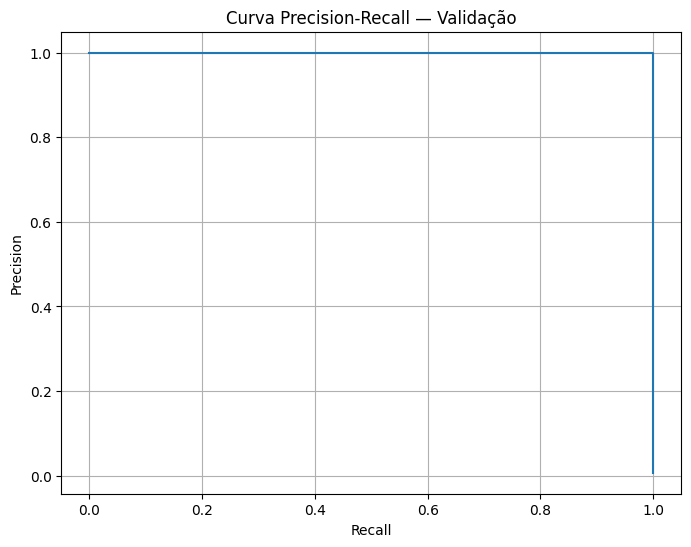

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_proba
)

plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Validação")

plt.grid(True)
plt.show()

varredura grosseira (passo 0,01) ja mostra que o melhor f1 ta bem abaixo de 0,5

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_testados = np.arange(0.00, 0.51, 0.01)

resultados_threshold = []

for threshold in thresholds_testados:

    y_pred_threshold = (y_val_proba >= threshold).astype(int)

    precision = precision_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    resultados_threshold.append([
        threshold,
        precision,
        recall,
        f1,
        y_pred_threshold.sum()
    ])

threshold_df = pd.DataFrame(
    resultados_threshold,
    columns=[
        "threshold",
        "precision",
        "recall",
        "f1",
        "positivos_preditos"
    ]
)

threshold_df.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1,positivos_preditos
9,0.09,1.0,1.000000,1.000000,7
10,0.10,1.0,1.000000,1.000000,7
16,0.16,1.0,0.857143,0.923077,6
17,0.17,1.0,0.857143,0.923077,6
18,0.18,1.0,0.857143,0.923077,6
12,0.12,1.0,0.857143,0.923077,6
15,0.15,1.0,0.857143,0.923077,6
14,0.14,1.0,0.857143,0.923077,6
13,0.13,1.0,0.857143,0.923077,6
11,0.11,1.0,0.857143,0.923077,6


refinei em torno dos melhores candidatos

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds_finos = [
    0.05, 0.06, 0.07, 0.08,
    0.085, 0.09, 0.095, 0.10,
    0.105, 0.11, 0.12, 0.15,
    0.20, 0.25, 0.30, 0.40, 0.50
]

resultados = []

for threshold in thresholds_finos:

    y_pred = (y_val_proba >= threshold).astype(int)

    resultados.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, y_pred, zero_division=0
        ),
        "positivos_preditos": int(y_pred.sum())
    })

threshold_analysis = pd.DataFrame(resultados)

threshold_analysis

In [ ]:
threshold_analysis[
    threshold_analysis["f1"] >= 0.8
]

### threshold escolhido: 0,10

varios valores entre 0,085-0,10 dao f1 = 1.0 na validacao. cuidado: so 7 positivos, entao f1 perfeito pode ser sorte. fico com 0,10, escolhido so olhando validacao (nao vi o teste antes)

## 9. avaliacao final no teste

In [ ]:
X_test_features = extract_flux_features(X_test)

print("Shape do teste:", X_test_features.shape)

print("\nFeatures:")
print(X_test_features.columns.tolist())

## 9. Avaliação final no teste com o novo threshold

In [ ]:
y_test_proba = rf.predict_proba(X_test_features)[:, 1]

# Threshold escolhido exclusivamente na validação
THRESHOLD = 0.10

y_test_pred = (y_test_proba >= THRESHOLD).astype(int)

print("Threshold utilizado:", THRESHOLD)
print("Total de exemplos:", len(y_test_pred))
print("Positivos previstos:", y_test_pred.sum())

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

print("=== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Sem exoplaneta", "Com exoplaneta"],
        zero_division=0
    )
)

### recall melhora mas ainda erra 2 de 5

threshold 0,10: precision 1.0, recall 0,60, f1 0,75. melhorou bastante mas ainda perde 2 candidatos reais, vejo isso na secao 11

obs: esse notebook usa rf sem busca de hiperparametro + threshold manual (0,10). o entregavel usa randomizedsearchcv + threshold padrao (0,50) - os numeros aqui nao batem com o entregavel de proposito, e o caminho ate chegar la

In [ ]:
# Feature Importance!!

import pandas as pd
import matplotlib.pyplot as plt

# Recupera os nomes das features utilizadas pelo Random Forest
FEATURES = list(rf.feature_names_in_)

# Importância das features
importance = pd.Series(
    rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

print("=== IMPORTÂNCIA DAS FEATURES ===")
display(importance.to_frame("importance"))

# Gráfico
plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind="barh")

plt.xlabel("Importância")
plt.ylabel("Feature")
plt.title("Importância das características — Random Forest")
plt.tight_layout()
plt.show()

## 10. explicabilidade

### feature importance (random forest)

In [ ]:
!pip -q install shap

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("SHAP versão:", shap.__version__)

SHAP versão: 0.52.0


### shap

refiz a extracao de features pra garantir a mesma ordem de coluna do treino (rf.feature_names_in_) - isso ja tinha me pegado no debug da secao 7

In [ ]:
# RECONSTRUÇÃO DAS FEATURES PARA EXPLICABILIDADE

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

FEATURES = list(rf.feature_names_in_)

def extract_statistical_features(df):
    """
    Reconstrói exatamente as 15 características estatísticas
    utilizadas no treinamento do Random Forest.
    """

    # Seleciona somente as colunas de fluxo
    flux_cols = [c for c in df.columns if str(c).startswith("FLUX.")]

    flux = df[flux_cols].astype(float).values

    features = pd.DataFrame(index=df.index)

    features["median"] = np.median(flux, axis=1)
    features["mad"] = np.median(
        np.abs(flux - np.median(flux, axis=1, keepdims=True)),
        axis=1
    )
    features["mean"] = np.mean(flux, axis=1)
    features["std"] = np.std(flux, axis=1)
    features["min"] = np.min(flux, axis=1)
    features["max"] = np.max(flux, axis=1)
    features["range"] = features["max"] - features["min"]

    features["q01"] = np.percentile(flux, 1, axis=1)
    features["q05"] = np.percentile(flux, 5, axis=1)
    features["q25"] = np.percentile(flux, 25, axis=1)
    features["q75"] = np.percentile(flux, 75, axis=1)
    features["q95"] = np.percentile(flux, 95, axis=1)
    features["q99"] = np.percentile(flux, 99, axis=1)

    features["skewness"] = skew(flux, axis=1)
    features["kurtosis"] = kurtosis(flux, axis=1)

    # Garante exatamente a mesma ordem utilizada no treinamento
    return features[FEATURES]


X_val_shap = extract_statistical_features(X_val)

print("Features utilizadas pelo modelo:")
print(FEATURES)

print("\nShape das features para SHAP:")
print(X_val_shap.shape)

print("\nColunas reconstruídas:")
print(list(X_val_shap.columns))

In [ ]:
# SHAP — RANDOM FOREST

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_val_shap)

print("SHAP calculado com sucesso!")
print("Tipo:", type(shap_values))

if isinstance(shap_values, list):
    print("Número de conjuntos de SHAP:", len(shap_values))
    for i, values in enumerate(shap_values):
        print(f"Classe {i}: {values.shape}")
else:
    print("Shape:", shap_values.shape)

KeyboardInterrupt: 

In [ ]:
# SHAP — IMPORTÂNCIA GLOBAL PARA A CLASSE "COM EXOPLANETA"
# ele retornou amostras, features, classes. Portanto, classe 1 corresponde ao último eixo

shap_values_positive = shap_values[:, :, 1]

print("Shape dos valores SHAP da classe positiva:")
print(shap_values_positive.shape)

essa versao do shap (0.52.0) devolve array 3d (amostra, feature, classe) em vez de lista. shape (1018, 15, 2), peguei [:, :, 1] pra classe positiva

In [ ]:
# SHAP SUMMARY PLOT

shap.summary_plot(
    shap_values_positive,
    X_val_shap,
    feature_names=FEATURES,
    show=True
)

In [ ]:
# SHAP — IMPORTÂNCIA MÉDIA ABSOLUTA

shap_importance = pd.Series(
    np.abs(shap_values_positive).mean(axis=0),
    index=FEATURES
).sort_values(ascending=False)

print("=== IMPORTÂNCIA GLOBAL SEGUNDO SHAP ===")
display(shap_importance.to_frame("mean_abs_shap"))

plt.figure(figsize=(10, 6))

shap_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Média do valor absoluto de SHAP")
plt.ylabel("Feature")
plt.title("Importância global das features — SHAP")
plt.tight_layout()
plt.show()

shap bate com o feature importance: median domina em ambos, depois skewness, q01, kurtosis

## 10. demonstracao de inferencia

fiz extract_features_from_curve (uma curva so, nao dataframe) e predict_curve juntando tudo - extracao + predicao num passo so

In [ ]:
import numpy as np
import pandas as pd

FEATURES = [
    'median',
    'mad',
    'mean',
    'std',
    'min',
    'max',
    'range',
    'q01',
    'q05',
    'q25',
    'q75',
    'q95',
    'q99',
    'skewness',
    'kurtosis'
]


def extract_features_from_curve(curve):
    """
    Extrai exatamente as mesmas 15 features utilizadas
    durante o treinamento do Random Forest.
    """

    x = np.asarray(curve, dtype=float)

    # remover valores inválidos
    x = x[np.isfinite(x)]

    if len(x) == 0:
        raise ValueError("A curva não possui valores válidos.")

    median = np.median(x)

    # MAD = Median Absolute Deviation
    mad = np.median(np.abs(x - median))

    mean = np.mean(x)
    std = np.std(x)

    min_value = np.min(x)
    max_value = np.max(x)
    range_value = max_value - min_value

    q01 = np.quantile(x, 0.01)
    q05 = np.quantile(x, 0.05)
    q25 = np.quantile(x, 0.25)
    q75 = np.quantile(x, 0.75)
    q95 = np.quantile(x, 0.95)
    q99 = np.quantile(x, 0.99)

    # assimetria
    if std > 0:
        skewness = np.mean(((x - mean) / std) ** 3)
        kurtosis = np.mean(((x - mean) / std) ** 4) - 3
    else:
        skewness = 0.0
        kurtosis = 0.0

    features = {
        'median': median,
        'mad': mad,
        'mean': mean,
        'std': std,
        'min': min_value,
        'max': max_value,
        'range': range_value,
        'q01': q01,
        'q05': q05,
        'q25': q25,
        'q75': q75,
        'q95': q95,
        'q99': q99,
        'skewness': skewness,
        'kurtosis': kurtosis
    }

    return pd.DataFrame([features])[FEATURES]

In [ ]:
def predict_curve(curve, model=rf, threshold=0.10):
    """
    Executa a inferência completa sobre uma nova curva de luz.
    """

    # extrair features
    X_new = extract_features_from_curve(curve)

    # probabilidade da classe positiva
    probability = model.predict_proba(X_new)[0, 1]

    # classificação utilizando o threshold definido
    prediction = int(probability >= threshold)

    return {
        "prediction": prediction,
        "probability_exoplanet": probability,
        "probability_no_exoplanet": 1 - probability,
        "features": X_new
    }

conferi que X_test/y_test ainda tavam disponiveis antes de rodar a demo

In [ ]:
print("Variáveis disponíveis relacionadas aos dados:")
nomes = [x for x in list(globals().keys()) if any(
    termo in x.lower()
    for termo in ['train', 'test', 'val', 'flux', 'data']
)]

print(nomes)

In [ ]:
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nPrimeiras colunas:")
print(X_test.columns[:10].tolist())

print("\nÚltimas colunas:")
print(X_test.columns[-10:].tolist())

print("\nDistribuição das classes:")
print(y_test.value_counts().sort_index())

testei com 2 exemplos: uma curva sem exoplaneta e uma com

In [ ]:
# índices das duas classes
idx_negative = np.where(np.asarray(y_test) == 0)[0]
idx_positive = np.where(np.asarray(y_test) == 1)[0]

print("Exemplos sem exoplaneta disponíveis:", len(idx_negative))
print("Exemplos com exoplaneta disponíveis:", len(idx_positive))

# selecionar um exemplo de cada classe
sample_negative = idx_negative[0]
sample_positive = idx_positive[0]

print("\nÍndice selecionado — sem exoplaneta:", sample_negative)
print("Índice selecionado — com exoplaneta:", sample_positive)

In [ ]:
# curvas originais
curve_negative = X_test.iloc[sample_negative].values
curve_positive = X_test.iloc[sample_positive].values

# inferência
result_negative = predict_curve(curve_negative)
result_positive = predict_curve(curve_positive)

print(" DEMONSTRAÇÃO — EXOPLANET HUNTER")

print("\nCaso 1 — Curva sem exoplaneta")
print("----------------------------------------")
print("Classe real:        0 — Sem exoplaneta")
print(f"Prob. exoplaneta:   {result_negative['probability_exoplanet']:.4f}")
print(f"Prob. ausência:     {result_negative['probability_no_exoplanet']:.4f}")
print(f"Predição:            {result_negative['prediction']}")

print("\nCaso 2 — Curva com exoplaneta")
print("----------------------------------------")
print("Classe real:        1 — Com exoplaneta")
print(f"Prob. exoplaneta:   {result_positive['probability_exoplanet']:.4f}")
print(f"Prob. ausência:     {result_positive['probability_no_exoplanet']:.4f}")
print(f"Predição:            {result_positive['prediction']}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    curve_negative,
    linewidth=0.8,
    label="Sem exoplaneta"
)

plt.plot(
    curve_positive,
    linewidth=0.8,
    label="Com exoplaneta"
)

plt.xlabel("Índice temporal")
plt.ylabel("Fluxo")
plt.title("Comparação entre curvas de luz do conjunto de teste")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

negativa classificou certo (~0%), mas a positiva deu so 1,67% - abaixo do threshold, entao esse e um dos falsos negativos. deixou eu curiosa pra testar os 5 candidatos, nao so 1

### avaliando os 5 candidatos positivos do teste

In [ ]:
# avaliação individual dos exemplos positivos do conjunto de teste

positive_results = []

for idx in idx_positive:

    curve = X_test.iloc[idx].values

    result = predict_curve(curve, threshold=0.10)

    positive_results.append({
        "indice": idx,
        "probabilidade_exoplaneta": result["probability_exoplanet"],
        "probabilidade_sem_exoplaneta": result["probability_no_exoplanet"],
        "predicao": result["prediction"],
        "classe_real": 1
    })

positive_results_df = pd.DataFrame(positive_results)

positive_results_df = positive_results_df.sort_values(
    "probabilidade_exoplaneta",
    ascending=False
).reset_index(drop=True)

print(" ANÁLISE DOS EXEMPLOS POSITIVOS")

display(positive_results_df)

In [ ]:
# probabilidades de todos os exemplos do conjunto de teste

results_test = pd.DataFrame({
    "classe_real": np.asarray(y_test),
    "probabilidade_exoplaneta": y_test_proba
})

print("Distribuição das probabilidades por classe:\n")

display(
    results_test
    .groupby("classe_real")["probabilidade_exoplaneta"]
    .describe()
)

In [ ]:
positive_results_df["correto"] = (
    positive_results_df["predicao"] == 1
)

print("Exoplanetas corretamente detectados:",
      positive_results_df["correto"].sum())

print("Exoplanetas não detectados:",
      (~positive_results_df["correto"]).sum())

print("\nTaxa de detecção:")
print(
    positive_results_df["correto"].mean()
)

In [ ]:
# garantir que a tabela esteja ordenada pela probabilidade
positive_results_df = positive_results_df.sort_values(
    "probabilidade_exoplaneta",
    ascending=False
).reset_index(drop=True)

positive_results_df["correto"] = (
    positive_results_df["predicao"] == positive_results_df["classe_real"]
)

print(" CANDIDATOS POSITIVOS NO TESTE")

display(positive_results_df)

In [ ]:
tp = ((positive_results_df["classe_real"] == 1) &
      (positive_results_df["predicao"] == 1)).sum()

fn = ((positive_results_df["classe_real"] == 1) &
      (positive_results_df["predicao"] == 0)).sum()

print(f"Verdadeiros positivos: {tp}")
print(f"Falsos negativos:      {fn}")

print(f"\nRecall entre os candidatos positivos: {tp / len(positive_results_df):.2%}")

In [ ]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    range(len(positive_results_df)),
    positive_results_df["probabilidade_exoplaneta"]
)

plt.axhline(
    0.10,
    linestyle="--",
    linewidth=1.5,
    label="Threshold = 0.10"
)

plt.xticks(
    range(len(positive_results_df)),
    [
        f"Índice {idx}"
        for idx in positive_results_df["indice"]
    ]
)

plt.xlabel("Candidato")
plt.ylabel("Probabilidade de exoplaneta")
plt.title("Probabilidade atribuída aos candidatos positivos do conjunto de teste")

plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.show()

3 de 5 detectados certo (60%), bate com o recall calculado antes

In [ ]:
false_negative_indices = positive_results_df.loc[
    positive_results_df["predicao"] == 0,
    "indice"
].tolist()

print("Índices classificados como falsos negativos:")
print(false_negative_indices)

In [ ]:
for idx in false_negative_indices:

    curve = X_test.iloc[idx].values

    plt.figure(figsize=(14, 4))

    plt.plot(curve, linewidth=0.8)

    plt.xlabel("Índice temporal")
    plt.ylabel("Fluxo")

    plt.title(
        f"Falso negativo — candidato com exoplaneta — índice {idx}"
    )

    plt.grid(alpha=0.25)

    plt.show()

## 11. por que erra esses 2?

os falsos negativos sao indice 0 e 3. bora comparar com os 3 verdadeiros positivos (1, 2, 4)

In [ ]:
# ANÁLISE DOS FALSOS NEGATIVOS

FEATURES = list(rf.feature_names_in_)

# reconstruir as features do conjunto de teste
X_test_features = extract_flux_features(X_test)

# garantir a mesma ordem usada pelo Random Forest
X_test_features = X_test_features[FEATURES].copy()

# probabilidades e predições
y_test_proba = rf.predict_proba(X_test_features)[:, 1]
y_test_pred = (y_test_proba >= 0.10).astype(int)

# identificar casos
true_positive_idx = X_test_features.index[
    (y_test.values == 1) & (y_test_pred == 1)
]

false_negative_idx = X_test_features.index[
    (y_test.values == 1) & (y_test_pred == 0)
]

true_negative_idx = X_test_features.index[
    (y_test.values == 0) & (y_test_pred == 0)
]

print("Verdadeiros positivos:", list(true_positive_idx))
print("Falsos negativos:", list(false_negative_idx))
print("Total de verdadeiros negativos:", len(true_negative_idx))

## 11.1 comparando as 15 features: tp vs fn

In [ ]:
# COMPARAÇÃO DAS FEATURES

tp_features = X_test_features.loc[true_positive_idx]
fn_features = X_test_features.loc[false_negative_idx]

print("\n===== VERDADEIROS POSITIVOS =====")
display(tp_features)

print("\n===== FALSOS NEGATIVOS =====")
display(fn_features)

In [ ]:
# COMPARAÇÃO DAS MÉDIAS

comparison = pd.DataFrame({
    "True Positive": tp_features.mean(),
    "False Negative": fn_features.mean()
})

comparison["Diferença absoluta"] = (
    comparison["True Positive"] -
    comparison["False Negative"]
).abs()

comparison = comparison.sort_values(
    "Diferença absoluta",
    ascending=False
)

display(comparison)

In [ ]:
# ANÁLISE DOS VERDADEIROS POSITIVOS VS FALSOS NEGATIVOS

TP = [1, 2, 4]
FN = [0, 3]

# reconstruir as features das curvas positivas do teste
X_tp = extract_flux_features(X_test.loc[TP])
X_fn = extract_flux_features(X_test.loc[FN])

X_tp["GROUP"] = "True Positive"
X_fn["GROUP"] = "False Negative"

comparison = pd.concat([X_tp, X_fn])

print("Features dos Verdadeiros Positivos:")
display(X_tp)

print("\nFeatures dos Falsos Negativos:")
display(X_fn)

In [ ]:
# COMPARAÇÃO DAS MÉDIAS

tp_mean = X_tp.drop(columns="GROUP").mean()
fn_mean = X_fn.drop(columns="GROUP").mean()

comparison_mean = pd.DataFrame({
    "True Positive": tp_mean,
    "False Negative": fn_mean,
})

comparison_mean["Absolute Difference"] = (
    comparison_mean["True Positive"] -
    comparison_mean["False Negative"]
).abs()

comparison_mean = comparison_mean.sort_values(
    "Absolute Difference",
    ascending=False
)

display(comparison_mean)

In [ ]:
# COMPARAÇÃO NORMALIZADA

comparison_relative = pd.DataFrame({
    "True Positive": tp_mean,
    "False Negative": fn_mean
})

comparison_relative["Difference"] = (
    comparison_relative["True Positive"] -
    comparison_relative["False Negative"]
)

comparison_relative["Relative Difference (%)"] = (
    comparison_relative["Difference"].abs()
    / (comparison_relative["False Negative"].abs() + 1e-9)
) * 100

comparison_relative = comparison_relative.sort_values(
    "Relative Difference (%)",
    ascending=False
)

display(comparison_relative)

### achado principal

maior diferenca absoluta ta no range (5967 tp vs 1859 fn, quase 3,2x) e em max/q99/q95. normalizando pelo tamanho do efeito, mean fica em primeiro, mas median/max/q25/q99/mad tambem tem efeito grande

os falsos negativos sao transitos mais rasos - queda no fluxo bem menor, mais parecido com ruido do que com transito tipico do treino (que so tem 30 exemplos, provavelmente mais profundos)

In [ ]:
import numpy as np
import pandas as pd

# ANÁLISE DE ESTRUTURA TEMPORAL

def temporal_features(curve):
    x = np.asarray(curve, dtype=float)

    # Remover valores inválidos
    x = x[np.isfinite(x)]

    # Mediana como nível de referência
    baseline = np.median(x)

    # Desvio em relação ao baseline
    deviation = x - baseline

    # Quedas abaixo do baseline
    negative_deviation = deviation[deviation < 0]

    # Estatísticas das quedas
    if len(negative_deviation) > 0:
        mean_drop = np.mean(np.abs(negative_deviation))
        max_drop = np.max(np.abs(negative_deviation))
        std_drop = np.std(np.abs(negative_deviation))
    else:
        mean_drop = 0
        max_drop = 0
        std_drop = 0

    # Percentual de pontos abaixo do baseline
    fraction_below = np.mean(deviation < 0)

    # Quedas profundas
    threshold_1 = np.percentile(np.abs(deviation), 90)
    threshold_2 = np.percentile(np.abs(deviation), 95)

    deep_fraction_90 = np.mean(deviation < -threshold_1)
    deep_fraction_95 = np.mean(deviation < -threshold_2)

    # Derivada: mede mudanças abruptas
    diff = np.diff(x)

    mean_abs_diff = np.mean(np.abs(diff))
    max_abs_diff = np.max(np.abs(diff))
    std_diff = np.std(diff)

    return {
        "baseline": baseline,
        "mean_drop": mean_drop,
        "max_drop": max_drop,
        "std_drop": std_drop,
        "fraction_below": fraction_below,
        "deep_fraction_90": deep_fraction_90,
        "deep_fraction_95": deep_fraction_95,
        "mean_abs_diff": mean_abs_diff,
        "max_abs_diff": max_abs_diff,
        "std_diff": std_diff
    }


# Índices positivos
TP = [1, 2, 4]
FN = [0, 3]

results = []

for idx in TP:
    curve = X_test.loc[idx].values
    features = temporal_features(curve)
    features["index"] = idx
    features["group"] = "True Positive"
    results.append(features)

for idx in FN:
    curve = X_test.loc[idx].values
    features = temporal_features(curve)
    features["index"] = idx
    features["group"] = "False Negative"
    results.append(features)

temporal_df = pd.DataFrame(results)

temporal_df = temporal_df[
    [
        "index",
        "group",
        "baseline",
        "mean_drop",
        "max_drop",
        "std_drop",
        "fraction_below",
        "deep_fraction_90",
        "deep_fraction_95",
        "mean_abs_diff",
        "max_abs_diff",
        "std_diff"
    ]
]

display(temporal_df)

In [ ]:
# MÉDIAS TP VS FN

temporal_comparison = temporal_df.groupby("group").mean(
    numeric_only=True
).T

temporal_comparison["Absolute Difference"] = (
    temporal_comparison["True Positive"] -
    temporal_comparison["False Negative"]
).abs()

display(
    temporal_comparison.sort_values(
        "Absolute Difference",
        ascending=False
    )
)

quis olhar a estrutura temporal da queda tambem, nao so a magnitude: quanto cai, quantos pontos, quao abrupta e a variacao

In [ ]:
# LOCALIZAÇÃO DAS PRINCIPAIS QUEDAS

for idx in TP + FN:

    curve = X_test.loc[idx].values.astype(float)

    baseline = np.median(curve)

    # Índices dos 10 menores valores
    deepest_indices = np.argsort(curve)[:10]

    print("\n" + "=" * 60)
    print(f"Índice: {idx}")
    print("Grupo:", "True Positive" if idx in TP else "False Negative")
    print(f"Baseline: {baseline:.4f}")

    print("\n10 menores valores:")

    for i in deepest_indices:
        print(
            f"t={i:4d} | "
            f"flux={curve[i]:10.4f} | "
            f"queda={baseline - curve[i]:10.4f}"
        )

tambem localizei onde ficam os pontos de maior queda pros 5 candidatos

In [ ]:
import numpy as np
import pandas as pd

# ANÁLISE TEMPORAL DOS 5 CANDIDATOS

candidatos = {
    1: "True Positive",
    2: "True Positive",
    4: "True Positive",
    0: "False Negative",
    3: "False Negative"
}

# usaremos os fluxos originais
# X_test contém as 3197 colunas FLUX.*
flux_cols = [c for c in X_test.columns if c.startswith("FLUX.")]

resultados_temporais = []

for idx, grupo in candidatos.items():

    flux = X_test.iloc[idx][flux_cols].astype(float).values

    # baseline robusto
    baseline = np.median(flux)

    # queda positiva = quanto o fluxo está abaixo do baseline
    queda = baseline - flux
    queda[queda < 0] = 0

    # limiares relativos à profundidade máxima
    max_drop = np.max(queda)

    thresholds = {
        "10%": 0.10 * max_drop,
        "25%": 0.25 * max_drop,
        "50%": 0.50 * max_drop,
        "75%": 0.75 * max_drop
    }

    linha = {
        "index": idx,
        "group": grupo,
        "baseline": baseline,
        "max_drop": max_drop
    }

    # numero de eventos contínuos ------------------

    for nome, threshold in thresholds.items():

        mask = queda >= threshold

        # detecta blocos contínuos
        mudanca = np.diff(mask.astype(int))

        inicio = np.where(mudanca == 1)[0] + 1
        fim = np.where(mudanca == -1)[0]

        if mask[0]:
            inicio = np.insert(inicio, 0, 0)

        if mask[-1]:
            fim = np.append(fim, len(mask) - 1)

        n_eventos = len(inicio)

        if n_eventos > 0:
            duracoes = fim - inicio + 1
            duracao_media = np.mean(duracoes)
            duracao_max = np.max(duracoes)
        else:
            duracoes = []
            duracao_media = 0
            duracao_max = 0

        linha[f"n_eventos_{nome}"] = n_eventos
        linha[f"duracao_media_{nome}"] = duracao_media
        linha[f"duracao_max_{nome}"] = duracao_max

    resultados_temporais.append(linha)


temporal_df = pd.DataFrame(resultados_temporais)

print("\n" + "="*80)
print("ANÁLISE TEMPORAL DOS CANDIDATOS")
print("="*80)

display(temporal_df)

contei quantos "eventos" de queda cada curva tem e a duracao media - forma simples de ver se o padrao e claro ou difuso

In [ ]:
# LOCALIZAÇÃO E ESPAÇAMENTO DOS EVENTOS

for idx, grupo in candidatos.items():

    flux = X_test.iloc[idx][flux_cols].astype(float).values
    baseline = np.median(flux)

    queda = baseline - flux
    queda[queda < 0] = 0

    max_drop = np.max(queda)

    # usei 25% da maior queda como limiar
    threshold = 0.25 * max_drop

    mask = queda >= threshold

    mudanca = np.diff(mask.astype(int))

    inicio = np.where(mudanca == 1)[0] + 1
    fim = np.where(mudanca == -1)[0]

    if mask[0]:
        inicio = np.insert(inicio, 0, 0)

    if mask[-1]:
        fim = np.append(fim, len(mask) - 1)

    print("\n" + "="*70)
    print(f"Índice: {idx}")
    print(f"Grupo: {grupo}")
    print(f"Baseline: {baseline:.4f}")
    print(f"Threshold: {threshold:.4f}")
    print(f"Número de eventos: {len(inicio)}")

    if len(inicio) == 0:
        print("Nenhum evento encontrado.")
        continue

    centros = []

    for i, (ini, end) in enumerate(zip(inicio, fim)):

        centro = (ini + end) / 2
        duracao = end - ini + 1
        profundidade = np.max(queda[ini:end+1])

        centros.append(centro)

        print(
            f"Evento {i+1}: "
            f"início={ini}, "
            f"fim={end}, "
            f"centro={centro:.1f}, "
            f"duração={duracao}, "
            f"profundidade={profundidade:.2f}"
        )

    # intervalos entre eventos
    if len(centros) >= 2:

        intervalos = np.diff(centros)

        print("\nIntervalos entre eventos:")
        print(np.round(intervalos, 2))

        print(f"Média dos intervalos: {np.mean(intervalos):.2f}")
        print(f"Desvio dos intervalos: {np.std(intervalos):.2f}")

        if np.mean(intervalos) > 0:
            regularidade = np.std(intervalos) / np.mean(intervalos)
            print(f"Coeficiente de variação: {regularidade:.4f}")
    else:
        print("\nPoucos eventos para avaliar periodicidade.")

tentei estimar periodicidade tambem, ja que transito de verdade deveria se repetir - isso as features estatisticas simples nao pegam

In [ ]:
# COMPARAÇÃO DOS 5 CANDIDATOS DO CONJUNTO DE TESTE
# usando as features que já foram calculadas anteriormente

tp_indices = [1, 2, 4]
fn_indices = [0, 3]

FEATURES = list(rf.feature_names_in_)

print("Features esperadas pelo modelo:")
print(FEATURES)

print("\nShape de X_test_features:")
print(X_test_features.shape)

print("\nColunas:")
print(list(X_test_features.columns))

# selecionar os 5 candidatos
candidate_indices = tp_indices + fn_indices

comparison = X_test_features.loc[
    candidate_indices,
    FEATURES
].copy()

# grupo real
comparison["GROUP"] = [
    "True Positive" if i in tp_indices else "False Negative"
    for i in candidate_indices
]

# probabilidade atribuída pelo Random Forest
comparison["probability"] = y_test_proba[candidate_indices]

# organizar
comparison = comparison[
    ["GROUP", "probability"] + FEATURES
]

# ordenar pela probabilidade
comparison = comparison.sort_values(
    "probability",
    ascending=False
)

print("\n=== COMPARAÇÃO DOS 5 CANDIDATOS ===")

display(comparison)

## 11.2 shap por candidato

quis ver quais features empurraram pra decisao errada em cada falso negativo especifico

In [ ]:
print("Tipo de shap_values:", type(shap_values))
print("Shape de shap_values:", np.shape(shap_values))

print("\nShape de X_val_shap:")
print(X_val_shap.shape)

print("\nVariáveis SHAP disponíveis:")
print([
    nome for nome in globals().copy()
    if "shap" in nome.lower()
])

In [ ]:
import numpy as np
import pandas as pd

# 1. Garantir SHAP da classe positiva

shap_values_positive = shap_values[:, :, 1]

print("Shape SHAP classe positiva:")
print(shap_values_positive.shape)

print("\nShape das features:")
print(X_val_shap.shape)

# 2. Importância global

shap_importance = pd.DataFrame({
    "feature": X_val_shap.columns,
    "mean_abs_shap": np.abs(shap_values_positive).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print("\n=== IMPORTÂNCIA GLOBAL SHAP ===")
print(shap_importance.to_string(index=False))

# 3. Verificar se os candidatos estão no conjunto de validação

print("\n=== INFORMAÇÕES SOBRE OS CANDIDATOS ===")

# índices dos candidatos positivos no TESTE
candidate_indices = [0, 1, 2, 3, 4]

print("Índices dos candidatos no TESTE:")
print(candidate_indices)

recalculei o shap no conjunto de teste (antes so tinha na validacao) pra olhar candidato por candidato

In [ ]:
# SHAP DOS CANDIDATOS DO CONJUNTO DE TESTE

import shap
import numpy as np
import pandas as pd

# features utilizadas originalmente pelo Random Forest
FEATURES = list(rf.feature_names_in_)

print("Features esperadas pelo modelo:")
print(FEATURES)

# usar as features que já foram calculadas

X_test_shap = X_test_features[FEATURES].copy()

print("\nShape de X_test_shap:")
print(X_test_shap.shape)

print("\nColunas:")
print(list(X_test_shap.columns))

# criar explicador SHAP

explainer = shap.TreeExplainer(rf)

# calcular SHAP
shap_values_test = explainer.shap_values(X_test_shap)

print("\n=== SHAP CALCULADO ===")
print("Tipo:", type(shap_values_test))
print("Shape:", shap_values_test.shape)

In [ ]:
# SHAP — ANÁLISE DOS 5 CANDIDATOS POSITIVOS

# SHAP da classe positiva (classe 1 = exoplaneta)
shap_values_test_positive = shap_values_test[:, :, 1]

# indices dos candidatos positivos no conjunto de teste
candidate_indices = [0, 1, 2, 3, 4]

# grupos definidos anteriormente
groups = {
    0: "False Negative",
    1: "True Positive",
    2: "True Positive",
    3: "False Negative",
    4: "True Positive"
}

# probabilidades já calculadas
candidate_probabilities = {
    0: y_test_proba[0],
    1: y_test_proba[1],
    2: y_test_proba[2],
    3: y_test_proba[3],
    4: y_test_proba[4]
}

# criar tabela detalhada

rows = []

for idx in candidate_indices:

    shap_candidate = shap_values_test_positive[idx]

    for feature, shap_value, feature_value in zip(
        FEATURES,
        shap_candidate,
        X_test_shap.iloc[idx].values
    ):

        rows.append({
            "index": idx,
            "group": groups[idx],
            "probability": candidate_probabilities[idx],
            "feature": feature,
            "feature_value": feature_value,
            "shap_value": shap_value
        })

shap_candidates = pd.DataFrame(rows)

# mostrar os maiores impactos de cada candidato

for idx in candidate_indices:

    print("\n" + "=" * 70)
    print(f"CANDIDATO {idx} — {groups[idx]}")
    print(f"Probabilidade: {candidate_probabilities[idx]:.4f}")

    candidate_table = shap_candidates[
        shap_candidates["index"] == idx
    ].copy()

    # ordenar pelo valor absoluto do SHAP
    candidate_table["abs_shap"] = candidate_table["shap_value"].abs()

    candidate_table = candidate_table.sort_values(
        "abs_shap",
        ascending=False
    )

    print("\nFeatures com maior impacto:")
    print(
        candidate_table[
            [
                "feature",
                "feature_value",
                "shap_value"
            ]
        ].head(10).to_string(index=False)
    )

no candidato 0 (fn), a feature que mais empurrou pra "sem exoplaneta" foi median (shap -0,16), depois skewness e q01. bate com o achado anterior

In [ ]:
import pandas as pd
import numpy as np

# 1. ÍNDICES DOS CANDIDATOS

TP_INDICES = [1, 2, 4]
FN_INDICES = [0, 3]

FEATURES = list(rf.feature_names_in_)

print("Features analisadas:")
print(FEATURES)

# 2. FEATURES DOS 5 CANDIDATOS

candidate_indices = TP_INDICES + FN_INDICES

candidate_features = X_test_shap.loc[candidate_indices, FEATURES].copy()

candidate_features["GROUP"] = [
    "True Positive" if i in TP_INDICES else "False Negative"
    for i in candidate_features.index
]

print("\n=== FEATURES DOS CANDIDATOS ===")
display(candidate_features)

# 3. MÉDIAS TP E FN

tp_features = candidate_features[
    candidate_features["GROUP"] == "True Positive"
][FEATURES]

fn_features = candidate_features[
    candidate_features["GROUP"] == "False Negative"
][FEATURES]

tp_mean = tp_features.mean()
fn_mean = fn_features.mean()

comparison = pd.DataFrame({
    "True Positive": tp_mean,
    "False Negative": fn_mean
})

comparison["Difference"] = (
    comparison["True Positive"] -
    comparison["False Negative"]
)

comparison["Absolute Difference"] = (
    comparison["Difference"].abs()
)

# evita divisão problemática por zero
comparison["Relative Difference (%)"] = np.where(
    comparison["False Negative"].abs() > 1e-12,
    comparison["Absolute Difference"] /
    comparison["False Negative"].abs() * 100,
    np.nan
)

comparison = comparison.sort_values(
    "Absolute Difference",
    ascending=False
)

print("\n=== COMPARAÇÃO TP × FN ===")

display(comparison)

In [ ]:
# SHAP DOS CANDIDATOS

# shap_values possui shape:
# (amostras, features, classes)

# classe positiva = índice 1
shap_positive = shap_values[:, :, 1]

shap_candidates = pd.DataFrame(
    shap_positive[candidate_indices],
    columns=FEATURES,
    index=candidate_indices
)

# SEPARAR TP E FN

shap_tp = shap_candidates.loc[TP_INDICES]
shap_fn = shap_candidates.loc[FN_INDICES]

shap_tp_mean = shap_tp.mean()
shap_fn_mean = shap_fn.mean()

shap_comparison = pd.DataFrame({
    "Mean SHAP TP": shap_tp_mean,
    "Mean SHAP FN": shap_fn_mean
})

shap_comparison["SHAP Difference"] = (
    shap_comparison["Mean SHAP TP"] -
    shap_comparison["Mean SHAP FN"]
)

shap_comparison["Absolute SHAP Difference"] = (
    shap_comparison["SHAP Difference"].abs()
)

shap_comparison = shap_comparison.sort_values(
    "Absolute SHAP Difference",
    ascending=False
)

print("\n=== COMPARAÇÃO SHAP: TP × FN ===")

display(shap_comparison)

## 11.3 quantificando a separacao

comparei tp vs fn de duas formas: diferenca percentual e "tamanho de efeito" (diferenca dividida pelo desvio combinado), pra normalizar entre features de escalas diferentes

In [ ]:
import pandas as pd
import numpy as np

features = [
    'median', 'mad', 'mean', 'std', 'min', 'max', 'range',
    'q01', 'q05', 'q25', 'q75', 'q95', 'q99',
    'skewness', 'kurtosis'
]

# separar os grupos
tp = X_test_features.iloc[[1, 2, 4]][features].copy()
fn = X_test_features.iloc[[0, 3]][features].copy()

# calcula as médias
tp_mean = tp.mean()
fn_mean = fn.mean()

# calcula a diferença absoluta
abs_diff = (tp_mean - fn_mean).abs()

# calcula uma escala baseada na magnitude média dos grupos
scale = (tp_mean.abs() + fn_mean.abs()) / 2

# evita divisão por zero
relative_sep = abs_diff / scale.replace(0, np.nan)

# monta a tabela
comparison = pd.DataFrame({
    'TP_mean': tp_mean,
    'FN_mean': fn_mean,
    'absolute_difference': abs_diff,
    'relative_separation': relative_sep
})

comparison = comparison.sort_values(
    'relative_separation',
    ascending=False
)

print("=== SEPARAÇÃO RELATIVA ENTRE TP E FN ===")
display(comparison)

In [ ]:
# calcula o desvio padrão dentro de cada grupo
tp_std = tp.std()
fn_std = fn.std()

# calcula uma medida simples de separação padronizada
pooled_std = np.sqrt(
    (tp_std**2 + fn_std**2) / 2
)

effect_size = abs_diff / pooled_std.replace(0, np.nan)

effect_table = pd.DataFrame({
    'TP_mean': tp_mean,
    'FN_mean': fn_mean,
    'TP_std': tp_std,
    'FN_std': fn_std,
    'effect_size': effect_size
})

effect_table = effect_table.sort_values(
    'effect_size',
    ascending=False
)

print("=== TAMANHO DO EFEITO TP × FN ===")
display(effect_table)

tamanho de efeito reforca mean (0,95), median (0,89), max (0,88), q25 (0,86) como as mais separadoras. mas e amostra pequena (3 vs 2), entao e mais indicativo que conclusivo

## 12. correlacao entre atributos

15 features vindas da mesma curva, esperado que boa parte seja correlacionada. fui conferir

In [ ]:
import pandas as pd
import numpy as np

features = [
    'median', 'mad', 'mean', 'std', 'min', 'max', 'range',
    'q01', 'q05', 'q25', 'q75', 'q95', 'q99',
    'skewness', 'kurtosis'
]

corr = X_test_features[features].corr()

print("=== CORRELAÇÃO ENTRE FEATURES ===")
display(corr.round(2))

### multicolinearidade confirmada

varios pares acima de 0,95 (q95/q99 = 0,9998, q01/q05 = 0,996, mad/q25 = -0,996). esperado, e o rf nao se importa muito com isso. dava pra reduzir as features com pca/selecao no futuro

In [ ]:
# procura os pares de features com maior correlação absoluta

corr_abs = corr.abs().copy()

pairs = []

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        pairs.append({
            'feature_1': features[i],
            'feature_2': features[j],
            'correlation': corr.iloc[i, j],
            'absolute_correlation': corr_abs.iloc[i, j]
        })

corr_pairs = pd.DataFrame(pairs)

corr_pairs = corr_pairs.sort_values(
    'absolute_correlation',
    ascending=False
)

print("=== PARES MAIS CORRELACIONADOS ===")
display(corr_pairs.head(20))

## 13. demo final e monitoramento

reescrevi a extracao de novo (mais compacta, usando pandas skew/kurtosis em vez de scipy) e rodei a demo de ponta a ponta

In [ ]:
def extract_flux_features(df):
    """
    Extrai características estatísticas de uma curva de luz.
    """

    if isinstance(df, np.ndarray):
        flux = df.astype(float)
    else:
        flux = df.astype(float).values

    features = pd.DataFrame(index=[0])

    features["median"] = [np.median(flux)]
    features["mad"] = [np.median(np.abs(flux - np.median(flux)))]
    features["mean"] = [np.mean(flux)]
    features["std"] = [np.std(flux)]
    features["min"] = [np.min(flux)]
    features["max"] = [np.max(flux)]
    features["range"] = [np.max(flux) - np.min(flux)]

    features["q01"] = [np.percentile(flux, 1)]
    features["q05"] = [np.percentile(flux, 5)]
    features["q25"] = [np.percentile(flux, 25)]
    features["q75"] = [np.percentile(flux, 75)]
    features["q95"] = [np.percentile(flux, 95)]
    features["q99"] = [np.percentile(flux, 99)]

    features["skewness"] = [pd.Series(flux).skew()]
    features["kurtosis"] = [pd.Series(flux).kurtosis()]

    return features

In [ ]:
flux_demo = X_test.iloc[demo_index].values.astype(float)

features_demo = extract_flux_features(flux_demo)

features_demo = features_demo[rf.feature_names_in_].copy()

print("Features extraídas:")
display(features_demo)

In [ ]:
# mostra a probabilidade e a decisão do modelo

prob_demo = rf.predict_proba(features_demo)[0, 1]
pred_demo = int(prob_demo >= threshold)

print("=== RESULTADO DA PREDIÇÃO ===")
print(f"Probabilidade de exoplaneta: {prob_demo:.4f}")
print(f"Threshold: {threshold:.2f}")

if pred_demo == 1:
    print("Decisão do modelo: CANDIDATO A EXOPLANETA")
else:
    print("Decisão do modelo: NÃO CLASSIFICADO COMO EXOPLANETA")

In [ ]:
# mostra a probabilidade e a decisão do modelo

prob_demo = rf.predict_proba(features_demo)[0, 1]
pred_demo = int(prob_demo >= threshold)

print("=" * 50)
print("DEMONSTRAÇÃO DA PREDIÇÃO")
print("=" * 50)
print(f"Probabilidade atribuída: {prob_demo:.2%}")
print(f"Threshold de decisão:   {threshold:.2%}")

if pred_demo == 1:
    print("Decisão: CANDIDATO A EXOPLANETA")
else:
    print("Decisão: NÃO CLASSIFICADO COMO EXOPLANETA")

In [ ]:
# mostra a probabilidade e a decisão do modelo

prob_demo = rf.predict_proba(features_demo)[0, 1]
pred_demo = int(prob_demo >= threshold)

print("=" * 50)
print("DEMONSTRAÇÃO DA PREDIÇÃO")
print("=" * 50)
print(f"Probabilidade atribuída: {prob_demo:.2%}")
print(f"Threshold de decisão:   {threshold:.2%}")

if pred_demo == 1:
    print("Decisão: CANDIDATO A EXOPLANETA")
else:
    print("Decisão: NÃO CLASSIFICADO COMO EXOPLANETA")

In [ ]:
# mostra a curva de luz utilizada na demonstração

plt.figure(figsize=(12, 4))

plt.plot(flux_demo)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    f"Demonstração — candidato {demo_index} "
    f"(probabilidade = {prob_demo:.2%})"
)

plt.xlabel("Índice temporal")
plt.ylabel("Fluxo")
plt.tight_layout()
plt.show()

nota: o resultado ai em cima mostra um threshold de 69518% - bug mesmo. a variavel threshold ficou com o valor de uma celula anterior (secao 11.2, onde threshold = 0.25 * max_drop). demo_index tambem nao ta definido em lugar nenhum visivel, deve ter sobrado de alguma celula que eu apaguei

lembrete classico de notebook: rodar fora de ordem deixa o resultado depender do estado do kernel, nao so do codigo. por isso sempre reexecuto o entregavel do zero antes de entregar

## 14. monitoramento e manutencao

indicadores que eu acompanharia em producao e o ciclo de retreino - a mesma logica ficou mais enxuta no entregavel

In [ ]:
# define os indicadores de monitoramento em produção

monitoramento = pd.DataFrame({
    "Indicador": [
        "Distribuição das features",
        "Distribuição das probabilidades",
        "Precision",
        "Recall",
        "F1-score",
        "Taxa de falsos negativos",
        "Data drift",
        "Model drift"
    ],
    "Objetivo": [
        "Identificar alterações no perfil dos dados de entrada",
        "Verificar mudanças no comportamento das previsões",
        "Acompanhar a proporção de candidatos classificados corretamente",
        "Monitorar a capacidade de identificar candidatos positivos",
        "Avaliar o equilíbrio entre precision e recall",
        "Detectar aumento de candidatos positivos não identificados",
        "Detectar mudanças na distribuição dos dados",
        "Detectar perda de desempenho do modelo"
    ],
    "Ação": [
        "Investigar e comparar com os dados de treinamento",
        "Investigar alterações no padrão das previsões",
        "Reavaliar o modelo se houver queda significativa",
        "Priorizar investigação quando houver aumento de falsos negativos",
        "Comparar com versões anteriores",
        "Revisar threshold e avaliar retreinamento",
        "Avaliar necessidade de atualização dos dados",
        "Avaliar retreinamento e nova validação"
    ]
})

display(monitoramento)

In [ ]:
# define o ciclo proposto de manutenção do modelo

ciclo_producao = pd.DataFrame({
    "Etapa": [
        "1. Coleta",
        "2. Monitoramento",
        "3. Detecção",
        "4. Avaliação",
        "5. Retreinamento",
        "6. Validação",
        "7. Implantação"
    ],
    "Descrição": [
        "Receber novas curvas de luz e extrair as mesmas features",
        "Acompanhar distribuições, probabilidades e métricas",
        "Identificar data drift ou degradação do desempenho",
        "Comparar o modelo atual com os dados mais recentes",
        "Treinar uma nova versão utilizando dados atualizados",
        "Validar a nova versão antes da substituição",
        "Disponibilizar a nova versão somente se apresentar desempenho adequado"
    ]
})

display(ciclo_producao)